In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import logging
import os
import warnings
import itertools
from datetime import datetime, timedelta
from functools import partial
from pathlib import Path
from optimization_engines import dwave_nl_sharpe

# Load D-Wave API token from .env file
from dotenv import load_dotenv
load_dotenv()

SEED = 12
np.random.seed(SEED)
msg_level = logging.INFO
# Suppress all RuntimeWarnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Quantum Portfolio Optimization using D-Wave CQM Solver

In [2]:
# Create a logger
logger = logging.getLogger("inspect_results_logger")
logger.setLevel(msg_level)  # Set the level for this logger

### Path definition

In [3]:
benchmark_path = '../../data/benchmark_gspc.pkl'
source_path = '../../data/stocks_adjclose.pkl'

### Data loading

Ticker,ds,^GSPC
0,2011-01-03,1271.869995
1,2011-01-04,1270.199951
2,2011-01-05,1276.560059
3,2011-01-06,1273.849976
4,2011-01-07,1271.500000


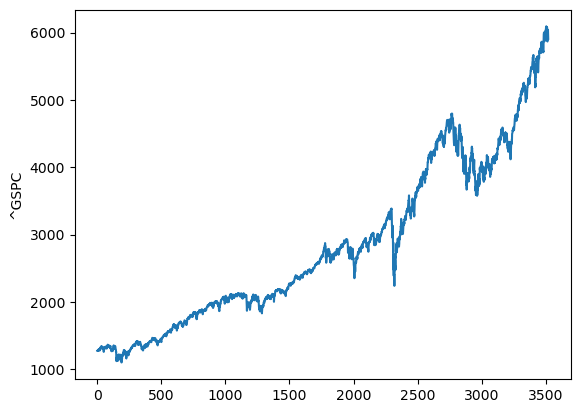

In [4]:
benchmark = pd.read_pickle(benchmark_path)
sns.lineplot(benchmark['^GSPC'])
benchmark.head()

In [5]:
source = pd.read_pickle(source_path)
print(source.shape)
# Check if any row contains at least one NaN
#print(source_wide.isnull().any(axis=1))
# Check if any value in the DataFrame is null
has_any_nan = source.isnull().values.any()
print("Any NaN in source_wide:", has_any_nan)
source.head()

(3522, 439)
Any NaN in source_wide: False


Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WRB,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,6.112024,18.971697,71.104691,11.828708,76.192101,14.700940,43.098133,26.977388,47.841393,38.200001
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,6.072278,18.631702,69.911537,11.702991,78.568939,14.763333,43.300457,26.565216,47.206047,37.840000
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,6.045782,18.713308,70.882263,12.068158,79.582596,14.675976,43.184826,26.691620,47.240875,37.799999
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,5.977333,18.577297,71.084503,11.984348,80.162842,14.663502,43.462337,26.878460,45.778728,37.480000
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,5.939793,18.486635,70.963158,12.313586,83.001091,14.794533,43.699345,27.213682,45.770027,37.599998


### Portfolio Stats

In [6]:
def portfolio_stats(weights, data):
    logger.info("=== portfolio_stats START ===")
    logger.info(f"Input weights shape: {np.array(weights).shape}")
    logger.info(f"Input data shape: {data.shape}")
    
    weights = np.array(weights)
    logger.info("Calculating log returns...")
    returns = np.log(data) - np.log(data.shift(1)) # log return to minimize fp error
    logger.info(f"Log returns calculated, shape: {returns.shape}")
    
    # CONSISTENT: Always use log returns, never pct_change()
    logger.info("Calculating portfolio return...")
    port_return = np.sum(returns.mean() * weights) 
    logger.info(f"Portfolio return: {port_return}")
    
    logger.info("Calculating portfolio volatility...")
    port_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() , weights)))
    logger.info(f"Portfolio volatility: {port_vol}")
    
    try:
        sharpe_ratio = port_return/port_vol
        logger.info(f"Sharpe ratio: {sharpe_ratio}")
    except Exception as e:
        logger.warning(f"Sharpe ratio calculation failed: {e}")
        sharpe_ratio = 0
    
    logger.info("=== portfolio_stats END ===")
    return sharpe_ratio, port_return, port_vol

### Data generator

Data generator to instantiate blocks on demand

In [7]:
def generate_data(df, benchmark, days_to_avg=30, days_to_opt=30, seed=SEED):
    df2 = df.reset_index()
    benchmark2 = benchmark.reset_index()
    elements = df2.sample(n=100, random_state=seed).index # definint a maximum of 100 different sampled initial dates
    for idx in elements:
        df_sample = df2.iloc[idx-days_to_avg:idx+days_to_opt, :]
        df_sample = df_sample.set_index('ds')
        df_sample_b = benchmark2.iloc[idx-days_to_avg:idx+days_to_opt, :]
        df_sample_b = df_sample_b.set_index('ds').drop(['index'], axis=1)
        yield df_sample, df_sample_b

### Backtest

In [8]:
def backtest(optimization_function, data, benchmark, budget, avg_period, opt_period, checkpoint_dir=None, period_id=None, resume_from_step=0, existing_portfolio_returns=None, existing_benchmark_returns=None, existing_weights_history=None):
    logger.info("="*80)
    logger.info("=== BACKTEST START ===")
    logger.info(f"Data shape: {data.shape}, Benchmark shape: {benchmark.shape}")
    logger.info(f"Budget: {budget}, Avg period: {avg_period}, Opt period: {opt_period}")
    logger.info(f"Checkpoint dir: {checkpoint_dir}, Period ID: {period_id}")
    logger.info(f"Resume from step: {resume_from_step}")
    
    # Create checkpoint directory if specified
    if checkpoint_dir and period_id is not None:
        os.makedirs(checkpoint_dir, exist_ok=True)
        logger.info(f"Created checkpoint directory: {checkpoint_dir}")
    
    portfolio_value = budget
    
    # Initialize or resume from existing data
    if resume_from_step > 0 and existing_portfolio_returns is not None:
        logger.info(f"Resuming backtest from step {resume_from_step + 1}")
        portfolio_returns = existing_portfolio_returns.copy()
        benchmark_returns = existing_benchmark_returns.copy()
        weights_history = existing_weights_history.copy()
    else:
        logger.info("Starting fresh backtest")
        portfolio_returns = []
        benchmark_returns = []
        weights_history = pd.DataFrame(index=data.index, columns=data.columns)
    
    portfolio_total_return = []
    portfolio_sharpe_ratios = []
    portfolio_value_history = pd.Series(index=data.index, name='Portfolio Value', dtype='float')
    portfolio_value_history.iloc[0] = portfolio_value
    
    logger.info(f"Starting backtest loop for {opt_period} iterations...")
    
    # Determine starting point
    start_iteration = resume_from_step if resume_from_step > 0 else 0
    
    for step_num in range(start_iteration + 1, opt_period + 1):
        # j tracks where to start the data slice from the beginning
        j = step_num - 1
        i = avg_period + step_num
        logger.info(f"\n--- Iteration {step_num}/{opt_period} (j={j}, i={i}) ---")
        
        df = data.iloc[j:i, :]
        logger.info(f"Data slice shape: {df.shape}, Date range: {df.index[0]} to {df.index[-1]}")
        
        # Use log returns for consistency with optimization functions
        logger.info("Calculating log returns for slice...")
        df_log_returns = np.log(df) - np.log(df.shift(1))
        df_log_returns = df_log_returns.dropna(axis=0)
        logger.info(f"Log returns shape after dropna: {df_log_returns.shape}")
        
        # Try optimization - if denied, stop the backtest
        try:
            weights = optimization_function(df)
        except RuntimeError as e:
            if "denied by user" in str(e):
                logger.warning(f"API call denied at step {step_num}. Stopping backtest.")
                print(f"\n⚠️  Backtest stopped at step {step_num}/{opt_period} due to API call denial.")
                print(f"  Completed steps: {step_num - 1}")
                print(f"  No checkpoint saved for step {step_num}.")
                # Return what we have so far
                break
            else:
                # Re-raise other RuntimeErrors
                raise
        
        logger.info(f"Optimization completed. Weights shape: {weights.shape}, Sum: {weights.sum():.6f}")
        logger.info(f"Weights min: {weights.min():.6f}, max: {weights.max():.6f}, non-zero count: {(weights > 0).sum()}")
        
        weights[weights < 0] = 0
        weights /= weights.sum()
        logger.info(f"Weights after normalization - Sum: {weights.sum():.6f}")
        
        weights_history.loc[df.index[-1]] = weights
        
        logger.info("Calculating portfolio change...")
        portfolio_change = df_log_returns.iloc[-1] * weights
        portfolio_return = portfolio_change.sum()
        logger.info(f"Portfolio return for this period: {portfolio_return:.6f}")
        
        portfolio_returns.append(portfolio_return)
        
        # Use log returns for benchmark as well
        logger.info("Calculating benchmark returns...")
        benchmark_log_returns = np.log(benchmark.iloc[j:i, :]) - np.log(benchmark.iloc[j:i, :].shift(1))
        benchmark_return = benchmark_log_returns.iloc[-1].values.tolist()[0]
        logger.info(f"Benchmark return for this period: {benchmark_return:.6f}")
        
        benchmark_returns.append(benchmark_return)
        
        logger.info("Calculating cumulative returns...")
        portfolio_cumulative_returns = np.cumprod([k + 1 for k in portfolio_returns])
        benchmark_cumulative_returns = np.cumprod([k + 1 for k in benchmark_returns])
        
        portfolio_mean_return = np.mean(portfolio_returns)
        benchmark_mean_return = np.mean(benchmark_returns)
        portfolio_volatility = np.std(portfolio_returns) 
        benchmark_volatility = np.std(benchmark_returns)
        logger.info(f"Portfolio mean return: {portfolio_mean_return:.6f}, volatility: {portfolio_volatility:.6f}")
        logger.info(f"Benchmark mean return: {benchmark_mean_return:.6f}, volatility: {benchmark_volatility:.6f}")
        
        try:
            sharpe_ratio = (portfolio_mean_return) / portfolio_volatility
            logger.info(f"Sharpe ratio: {sharpe_ratio:.6f}")
        except Exception as e:
            logger.warning(f"Sharpe ratio calculation failed: {e}")
            sharpe_ratio = 0
        portfolio_sharpe_ratios.append(sharpe_ratio)

        # Portfolio & Benchmark value
        benchmark_value = budget * benchmark_cumulative_returns[-1]
        portfolio_value = budget * portfolio_cumulative_returns[-1]
        logger.info(f"Portfolio value: ${portfolio_value:,.2f}, Benchmark value: ${benchmark_value:,.2f}")
        
        # Calculate normalized cumulative returns (starting from 0)
        portfolio_cumulative_normalized = portfolio_cumulative_returns - portfolio_cumulative_returns[0]
        benchmark_cumulative_normalized = benchmark_cumulative_returns - benchmark_cumulative_returns[0]
        
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(portfolio_cumulative_normalized, label='Portfolio', linewidth=2, color='#1f77b4')
        ax.plot(benchmark_cumulative_normalized, label='Benchmark', linewidth=2, color='#ff7f0e')
        ax.set_xlabel('Trading Days')
        ax.set_ylabel('Cumulative Returns')
        title_suffix = f' (Resumed from step {resume_from_step})' if resume_from_step > 0 else ''
        ax.set_title(f'Backtesting Progress - Step {step_num}/{opt_period}{title_suffix}')
        ax.legend(loc='upper left')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # ONLY save checkpoint if API call was approved and completed successfully
        if checkpoint_dir and period_id is not None:
            checkpoint_path = os.path.join(checkpoint_dir, f'period_{period_id}_step_{step_num}.pkl')
            checkpoint_data = {
                'step': step_num,
                'date': df.index[-1],
                'weights': weights,
                'portfolio_return': portfolio_return,
                'benchmark_return': benchmark_return,
                'portfolio_cumulative_returns': list(portfolio_cumulative_returns),
                'benchmark_cumulative_returns': list(benchmark_cumulative_returns),
                'portfolio_value': portfolio_value,
                'benchmark_value': benchmark_value,
                'sharpe_ratio': sharpe_ratio
            }
            write_pickle_dict(checkpoint_data, checkpoint_path)
            logger.info(f"✓ Checkpoint saved: {checkpoint_path}")

    logger.info("\nCalculating final cumulative returns...")
    portfolio_cumulative_returns = portfolio_cumulative_returns - portfolio_cumulative_returns[0]
    benchmark_cumulative_returns = benchmark_cumulative_returns - benchmark_cumulative_returns[0]
    logger.info(f"Final portfolio cumulative return: {portfolio_cumulative_returns[-1]:.6f}")
    logger.info(f"Final benchmark cumulative return: {benchmark_cumulative_returns[-1]:.6f}")

    # Final plot
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(portfolio_cumulative_returns, label='Portfolio', linewidth=2, color='#1f77b4')
    ax.plot(benchmark_cumulative_returns, label='Benchmark', linewidth=2, color='#ff7f0e')
    ax.set_xlabel('Trading Days')
    ax.set_ylabel('Cumulative Returns')
    ax.set_title('Backtesting Results - Final')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    logger.info("=== BACKTEST END ===")
    logger.info("="*80)
    return weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns

In [9]:
import pickle

def write_pickle_dict(data, file_path):
    """Pickles a dictionary and saves it to a file."""
    try:
        with open(file_path, 'wb') as f:  # Open the file in binary write mode ('wb')
            pickle.dump(data, f)
        print(f"Dictionary pickled and saved to {file_path}")
    except Exception as e:
        print(f"An error occurred while pickling: {e}")

def read_pickle_dict(file_path):
    try:
        with open(file_path, 'rb') as f:
            loaded_dict = pickle.load(f)
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
    except Exception as e:
        print(f"An error occurred: {e}")
    return loaded_dict


### Run Experiment Function

In [10]:
def run_experiment(results_path_template, data, benchmark, opt_fun, parameters, checkpoint_base_dir=None, force_resume=False):
    logger.info("\n" + "#"*100)
    logger.info("### RUN EXPERIMENT START ###")
    logger.info("#"*100)
    logger.info(f"Results path template: {results_path_template}")
    logger.info(f"Checkpoint base dir: {checkpoint_base_dir}")
    logger.info(f"Data shape: {data.shape}")
    logger.info(f"Benchmark shape: {benchmark.shape}")
    logger.info(f"Parameters: {parameters}")
    logger.info(f"Force resume: {force_resume}")

    n_periods = parameters['n_periods']
    days_to_avg = parameters['days_to_avg']
    days_to_opt = parameters['days_to_opt']
    budget = parameters['budget']
    
    # Create checkpoint base directory only if specified
    if checkpoint_base_dir:
        os.makedirs(checkpoint_base_dir, exist_ok=True)
        logger.info(f"Checkpoint base directory: {checkpoint_base_dir}")
    else:
        logger.info("No checkpoint directory specified - checkpoints disabled")
    
    logger.info(f"Creating data generator with n_periods={n_periods}...")
    datagen = generate_data(data, benchmark)

        
    for i in range(n_periods):
        logger.info(f"\n{'='*80}")
        logger.info(f"PERIOD {i+1}/{n_periods}")
        logger.info(f"{'='*80}")
        
        results_path = results_path_template.format(i)
        logger.info(f"Results path: {results_path}")
        
        # Check for existing checkpoint files
        existing_checkpoints = []
        if checkpoint_base_dir:
            import glob
            checkpoint_pattern = os.path.join(checkpoint_base_dir, f'period_{i}_step_*.pkl')
            existing_checkpoints = sorted(glob.glob(checkpoint_pattern))
            if existing_checkpoints:
                logger.info(f"Found {len(existing_checkpoints)} existing checkpoint files for period {i}")
        
        # Determine if we should process this period
        should_process = False
        if not os.path.exists(results_path):
            logger.info(f"Results file does not exist, will process period {i}")
            should_process = True
        elif force_resume and existing_checkpoints and len(existing_checkpoints) < days_to_opt:
            logger.info(f"Force resume enabled and incomplete checkpoints found ({len(existing_checkpoints)}/{days_to_opt}), will reprocess period {i}")
            should_process = True
            # Delete the incomplete results file
            os.remove(results_path)
            logger.info(f"Deleted incomplete results file: {results_path}")
        elif existing_checkpoints and len(existing_checkpoints) < days_to_opt:
            logger.info(f"Results file exists but checkpoints are incomplete ({len(existing_checkpoints)}/{days_to_opt})")
            logger.info(f"Set force_resume=True to resume from checkpoints, or delete {results_path}")
            should_process = False
        else:
            logger.info(f"Results file already exists and is complete")
            should_process = False
        
        if should_process:
            if not existing_checkpoints:
                logger.info(f"No existing checkpoints found for period {i}")
            
            try:
                logger.info("Getting next data sample from generator...")
                df, df_b = next(datagen)
                logger.info(f"Data sample retrieved - df shape: {df.shape}, benchmark shape: {df_b.shape}")
                print(f'initial date: {df.iloc[days_to_avg+1:, :].index[0]}')
                
                logger.info("Creating source data plot...")
                plt.figure(figsize=(12, 6))
                plt.plot(df.iloc[days_to_avg+1:days_to_avg+days_to_opt+1, :].sum(axis=1), label='Source')
                plt.plot(df_b, label='Benchmark')
                plt.legend(loc='upper left')
                plt.title('Source Data')
                plt.xlabel('Date')
                plt.ylabel('Stock Values')
                plt.show()
                
                # Determine if we can resume from checkpoints
                if existing_checkpoints and len(existing_checkpoints) < days_to_opt:
                    # Resume from last checkpoint
                    logger.info(f"Resuming from checkpoint {len(existing_checkpoints)}/{days_to_opt}")
                    logger.info(f"Loading existing {len(existing_checkpoints)} checkpoint files...")
                    
                    # Reconstruct state from checkpoints
                    weights_history = pd.DataFrame(index=df.index, columns=df.columns)
                    portfolio_value_history = pd.Series(index=df.index, name='Portfolio Value', dtype='float')
                    portfolio_value_history.iloc[0] = budget
                    portfolio_returns = []
                    benchmark_returns = []
                    
                    for checkpoint_file in existing_checkpoints:
                        checkpoint_data = read_pickle_dict(checkpoint_file)
                        step_num = checkpoint_data['step']
                        date_idx = checkpoint_data['date']
                        
                        if date_idx in weights_history.index:
                            weights_history.loc[date_idx] = checkpoint_data['weights']
                        
                        portfolio_returns.append(checkpoint_data['portfolio_return'])
                        benchmark_returns.append(checkpoint_data['benchmark_return'])
                    
                    logger.info(f"Loaded {len(existing_checkpoints)} steps, resuming from step {len(existing_checkpoints)+1}")
                    
                    # Resume backtest from where we left off
                    start_time = datetime.now()
                    weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns = backtest(
                        opt_fun, df, df_b, 
                        budget=budget, 
                        avg_period=days_to_avg,
                        opt_period=days_to_opt,
                        checkpoint_dir=checkpoint_base_dir,
                        period_id=i,
                        resume_from_step=len(existing_checkpoints),
                        existing_portfolio_returns=portfolio_returns,
                        existing_benchmark_returns=benchmark_returns,
                        existing_weights_history=weights_history
                    )
                    end_time = datetime.now()
                    dt = abs(end_time - start_time)
                    
                elif existing_checkpoints and len(existing_checkpoints) == days_to_opt:
                    # All checkpoints exist, just reconstruct the final result
                    logger.info(f"All {days_to_opt} checkpoint files found, reconstructing results...")
                    start_time = datetime.now()
                    
                    weights_history = pd.DataFrame(index=df.index, columns=df.columns)
                    portfolio_value_history = pd.Series(index=df.index, name='Portfolio Value', dtype='float')
                    portfolio_value_history.iloc[0] = budget
                    portfolio_returns = []
                    benchmark_returns = []
                    
                    for checkpoint_file in existing_checkpoints:
                        checkpoint_data = read_pickle_dict(checkpoint_file)
                        date_idx = checkpoint_data['date']
                        
                        if date_idx in weights_history.index:
                            weights_history.loc[date_idx] = checkpoint_data['weights']
                        
                        portfolio_returns.append(checkpoint_data['portfolio_return'])
                        benchmark_returns.append(checkpoint_data['benchmark_return'])
                    
                    # Calculate cumulative returns
                    portfolio_cumulative_returns = np.cumprod([k + 1 for k in portfolio_returns])
                    benchmark_cumulative_returns = np.cumprod([k + 1 for k in benchmark_returns])
                    portfolio_cumulative_returns = portfolio_cumulative_returns - portfolio_cumulative_returns[0]
                    benchmark_cumulative_returns = benchmark_cumulative_returns - benchmark_cumulative_returns[0]
                    
                    end_time = datetime.now()
                    dt = abs(end_time - start_time)
                    logger.info(f"Results reconstructed from checkpoints in {dt.total_seconds():.2f} seconds")
                    
                else:
                    # No checkpoints or starting fresh
                    logger.info(f"Starting backtest from beginning at {datetime.now()}")
                    start_time = datetime.now()
                    
                    weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns = backtest(
                        opt_fun, df, df_b, 
                        budget=budget, 
                        avg_period=days_to_avg,
                        opt_period=days_to_opt,
                        checkpoint_dir=checkpoint_base_dir,
                        period_id=i
                    )
                    
                    end_time = datetime.now()
                    dt = abs(end_time - start_time)
                
                logger.info(f'Backtest completed at {end_time}')
                logger.info(f'Total backtest time: {dt.total_seconds():.2f} seconds')
                logger.debug(f'portfolio cumulative returns: {portfolio_cumulative_returns}')
                
            except Exception as e: 
                logger.error(f'FAILED {results_path} due to {e}', exc_info=True)
                print(f'Failed {results_path} due to {e}')
                weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns = [], [], [], []
                dt = timedelta(0)

            logger.info("Saving results to pickle file...")
            result = {
                "round": i, 
                "start_date": df.index[0],
                "end_date": df.index[-1],
                "days_to_avg": days_to_avg,
                "days_to_opt": days_to_opt,
                "weights_history": weights_history,
                "portfolio_value_history": portfolio_value_history,
                "portfolio_cumulative_returns": portfolio_cumulative_returns,
                "benchmark_cumulative_returns": benchmark_cumulative_returns,
                "total_run_time": dt.total_seconds()
                }
            write_pickle_dict(result, results_path)
            logger.info(f"Results saved successfully to {results_path}")

        else:
            logger.info(f"Skipping period {i} - results already complete or force_resume not enabled")
            # Still need to advance the generator
            try:
                df, df_b = next(datagen)
            except StopIteration:
                pass
            
            # Load and plot existing results if they exist
            if os.path.exists(results_path):
                logger.info(f"Loading existing results from {results_path}...")
                results = read_pickle_dict(results_path)
                portfolio_cumulative_returns = results['portfolio_cumulative_returns']
                benchmark_cumulative_returns = results['benchmark_cumulative_returns']
                logger.info(f"Results loaded - portfolio return: {portfolio_cumulative_returns[-1] if len(portfolio_cumulative_returns) > 0 else 'N/A'}")

                # Plot the results
                logger.info("Creating results plot...")
                plt.figure(figsize=(12, 6))
                plt.plot(portfolio_cumulative_returns, label='Portfolio')
                plt.plot(benchmark_cumulative_returns, label='Benchmark')
                plt.legend(loc='upper left')
                plt.title('Backtesting Results')
                plt.xlabel('Date')
                plt.ylabel('Cumulative Returns')
                plt.show()
    
    logger.info("\n" + "#"*100)
    logger.info("### RUN EXPERIMENT END ###")
    logger.info("#"*100 + "\n")
    return None

### Performance Analysis Functions

In [11]:
def performance_summary(solver_configs, n_periods):
    """Generate performance summary across all periods for multiple solvers."""
    summary_data = []
    
    for config in solver_configs:
        solver_name = config['name']
        path_template = config['path_template']
        
        returns_data = []
        execution_times = []
        successful_periods = 0
        
        for period in range(n_periods):
            file_path = path_template.format(period)
            try:
                result_data = read_pickle_dict(file_path)
                if result_data is not None:
                    portfolio_returns = result_data.get('portfolio_cumulative_returns', [])
                    execution_time = result_data.get('total_run_time', 0)
                    
                    # Safe check for portfolio returns data
                    try:
                        if portfolio_returns is not None and len(portfolio_returns) > 0:
                            final_return = portfolio_returns[-1]
                            returns_data.append(final_return)
                            execution_times.append(execution_time)
                            successful_periods += 1
                    except (TypeError, IndexError):
                        pass
            except Exception as e:
                logger.debug(f'Could not process {file_path}: {e}')
        
        if returns_data:
            summary_data.append({
                'Solver': solver_name,
                'Periods': successful_periods,
                'Avg_Return': np.mean(returns_data),
                'Std_Return': np.std(returns_data),
                'Min_Return': np.min(returns_data),
                'Max_Return': np.max(returns_data),
                'Avg_Time': np.mean(execution_times),
                'Std_Time': np.std(execution_times),
                'Success_Rate': successful_periods / n_periods * 100
            })
    
    if summary_data:
        df = pd.DataFrame(summary_data)
        df = df.round(4)
        return df
    else:
        return pd.DataFrame()

### Global Parameters

CQM-specific parameters for quantum optimization

In [12]:
parameters = {
    "n_periods": 1,
    "days_to_avg": 30,
    "days_to_opt": 30,
    "budget": 1_000_000.0,
    "min_investment": 0.0001,
}

In [13]:
# D-Wave API Approval Wrapper
def dwave_with_approval(data, budget, min_investment):
    """Wrapper for D-Wave optimization that requires user approval before API calls."""
    print("\n" + "="*80)
    print("D-WAVE API CALL REQUEST")
    print("="*80)
    print(f"Dataset shape: {data.shape}")
    print(f"Number of assets: {data.shape[1]}")
    print(f"Budget: ${budget:,.0f}")
    print(f"Min investment: {min_investment}")
    print(f"Date range: {data.index[0]} to {data.index[-1]}")
    print("="*80)
    
    # Request user approval
    approval = input("\n⚠️  Approve D-Wave API call? (yes/no): ").strip().lower()
    
    if approval in ['yes', 'y']:
        print("✓ API call approved. Proceeding with D-Wave optimization...")
        result = dwave_nl_sharpe(data, budget, min_investment)
        print("✓ D-Wave optimization completed successfully.")
        return result
    else:
        print("✗ API call denied by user.")
        print("✗ No checkpoint will be saved for this step.")
        raise RuntimeError("D-Wave API call denied by user")

# D-Wave CQM QUBO Optimization - Define the optimization function with approval
opt_fun_dwave = partial(dwave_with_approval, budget=parameters["budget"], min_investment=parameters["min_investment"])

# Extract n_periods for use in performance analysis
n_periods = parameters['n_periods']

print(f"D-Wave CQM QUBO optimization function created with user approval requirement:")
print(f"  budget: {parameters['budget']}")
print(f"  min_investment: {parameters['min_investment']}")
print(f"  n_periods: {n_periods}")
print(f"\n⚠️  IMPORTANT NOTES:")
print(f"  - User approval will be required for EACH D-Wave API call")
print(f"  - Checkpoints are ONLY saved after successful API calls")
print(f"  - If you deny an API call, NO checkpoint will be saved for that step")
print(f"  - The backtest will stop if an API call is denied")

D-Wave CQM QUBO optimization function created with user approval requirement:
  budget: 1000000.0
  min_investment: 0.0001
  n_periods: 1

⚠️  IMPORTANT NOTES:
  - User approval will be required for EACH D-Wave API call
  - Checkpoints are ONLY saved after successful API calls
  - If you deny an API call, NO checkpoint will be saved for that step
  - The backtest will stop if an API call is denied


### Experiment: Wide Dataset (Stocks + ETFs)

In [14]:
source_path_extended = '../../data/etfs_close.pkl'

In [15]:
source_extended = pd.read_pickle(source_path_extended)
source_extended.head()

Ticker,ds,AADR,ACWI,ACWX,AFG,AGG,AMLP,BIL,BIV,BND,...,XLP,XLU,XLV,XLY,XME,XOP,XPH,XRT,XSD,XTNT
0,2011-01-03,26.494179,35.018154,30.182961,14.173727,71.489235,26.573900,76.281036,50.488926,53.083935,...,19.910189,19.169912,24.896574,31.685013,57.138588,168.841461,17.785585,19.920353,25.601683,1074.0
1,2011-01-04,26.450108,34.981026,30.019852,14.104879,71.509521,26.491484,76.281036,50.562424,53.090553,...,19.855919,19.261232,24.974888,31.509201,56.714920,167.352570,17.651617,19.548199,25.860556,1032.0
2,2011-01-05,26.291458,34.981026,29.992662,14.066156,71.164383,26.458506,76.281036,50.188774,52.858776,...,19.862703,19.139469,25.029711,31.768719,57.097866,167.922791,17.774096,19.531855,26.151806,1050.0
3,2011-01-06,26.291458,34.758274,29.727602,14.264087,71.177925,26.458506,76.281036,50.378658,52.905167,...,19.794865,19.157736,25.131519,31.576189,56.389015,167.099167,17.873608,19.253756,26.558626,1026.0
4,2011-01-07,26.150438,34.632030,29.578085,14.195246,71.408035,26.491484,76.264374,50.678814,53.103794,...,19.693110,19.224695,25.115862,31.559439,56.112007,167.701004,17.892746,19.196499,26.697304,1050.0


In [16]:
source_wide = pd.merge(source, source_extended, on='ds', how='left').set_index('ds').dropna()
print(source_wide.shape)
# Check if any row contains at least one NaN
#print(source_wide.isnull().any(axis=1))
# Check if any value in the DataFrame is null
has_any_nan = source_wide.isnull().values.any()
print("Any NaN in source_wide:", has_any_nan)
source_wide.head()

(3521, 680)
Any NaN in source_wide: False


Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,XLP,XLU,XLV,XLY,XME,XOP,XPH,XRT,XSD,XTNT
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,19.910189,19.169912,24.896574,31.685013,57.138588,168.841461,17.785585,19.920353,25.601683,1074.0
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,19.855919,19.261232,24.974888,31.509201,56.714920,167.352570,17.651617,19.548199,25.860556,1032.0
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,19.862703,19.139469,25.029711,31.768719,57.097866,167.922791,17.774096,19.531855,26.151806,1050.0
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,19.794865,19.157736,25.131519,31.576189,56.389015,167.099167,17.873608,19.253756,26.558626,1026.0
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,19.693110,19.224695,25.115862,31.559439,56.112007,167.701004,17.892746,19.196499,26.697304,1050.0


initial date: 2014-01-13 00:00:00


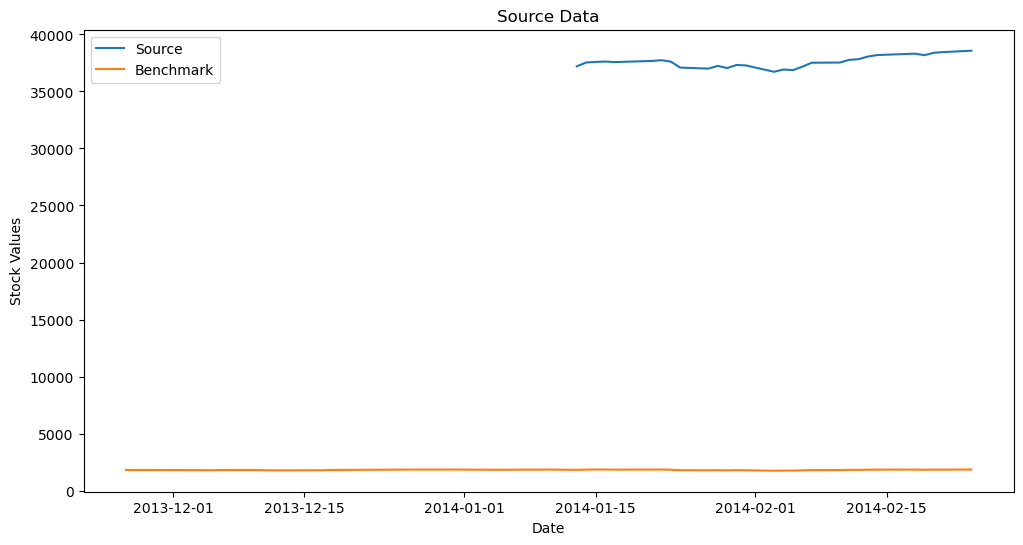


D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2013-11-27 00:00:00 to 2014-01-13 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'CE', 'CF', 'CHD', 'CHRW', 'CHTR', 'CI', 'CINF', 'CL', 'CLX', 'CMCSA', 'CME', 'CMG', 'CMI', 'CMS', '

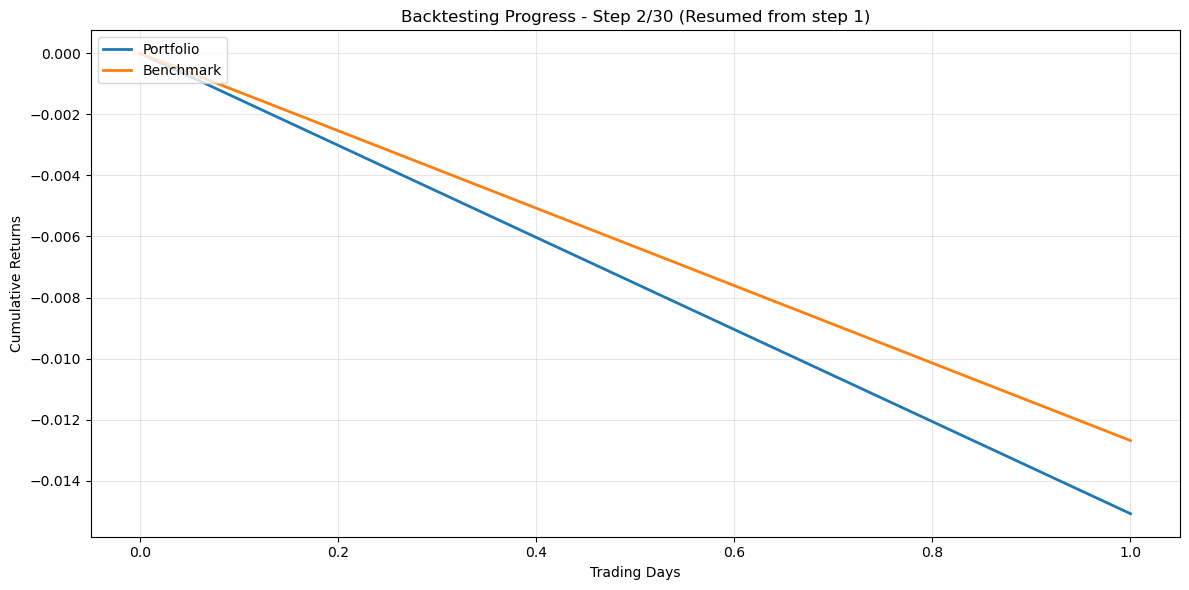

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_2.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2013-11-29 00:00:00 to 2014-01-14 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'C

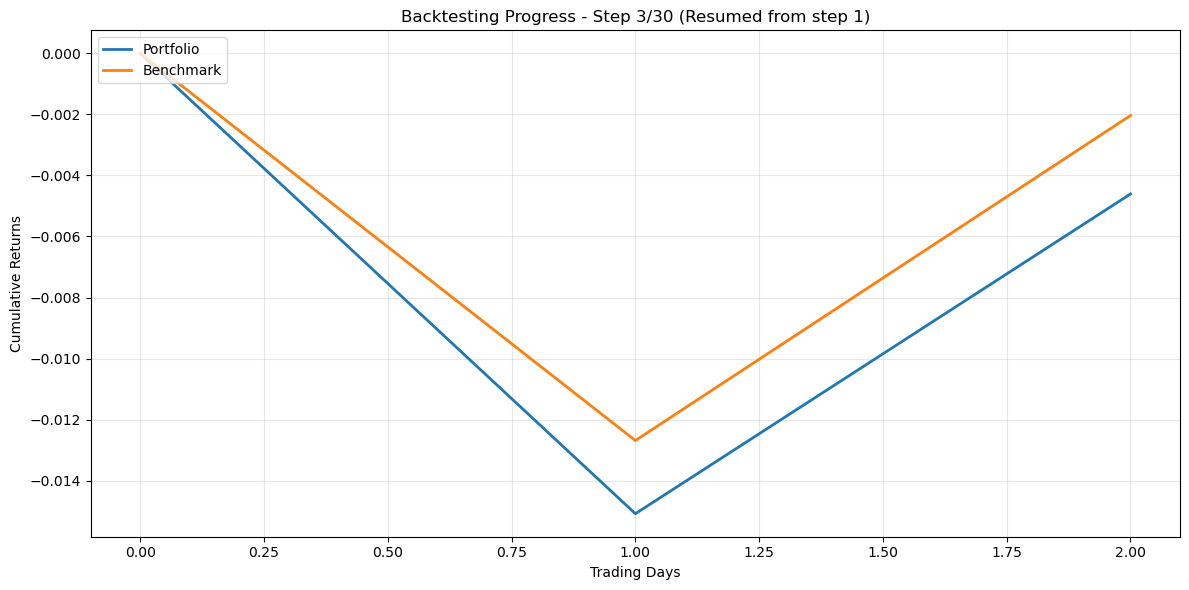

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_3.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2013-12-02 00:00:00 to 2014-01-15 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'C

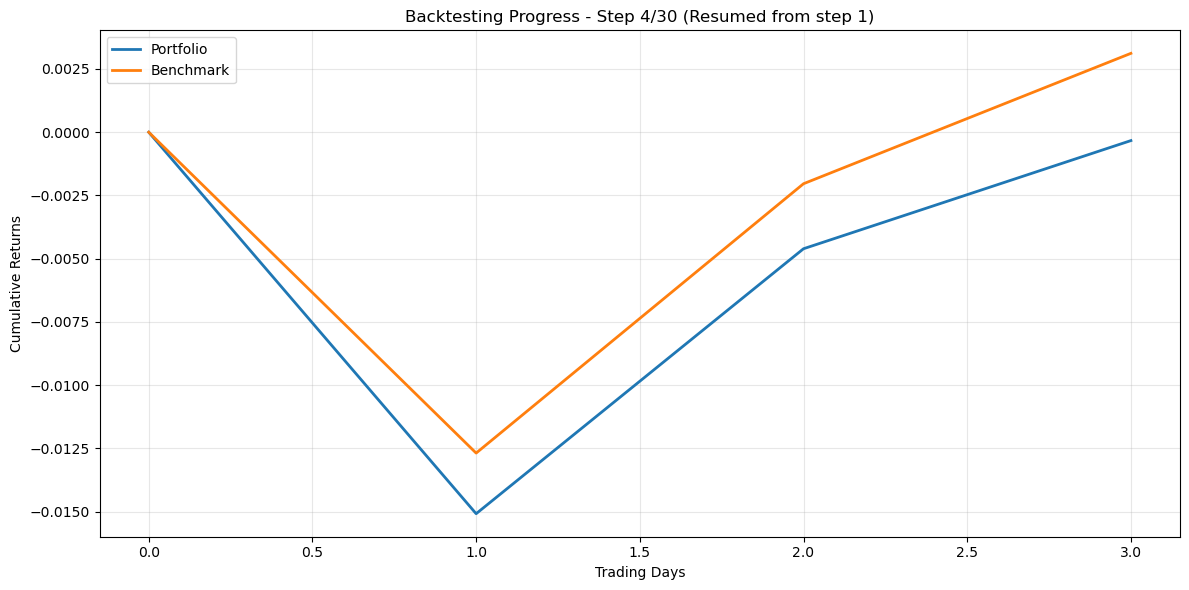

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_4.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2013-12-03 00:00:00 to 2014-01-16 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'C

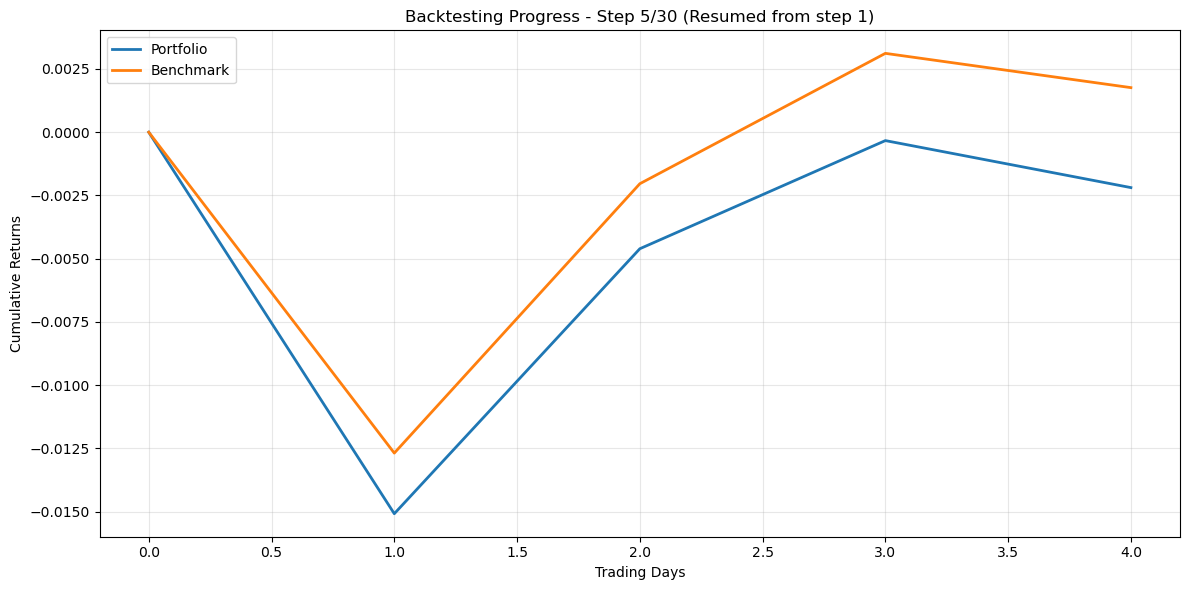

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_5.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2013-12-04 00:00:00 to 2014-01-17 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'C

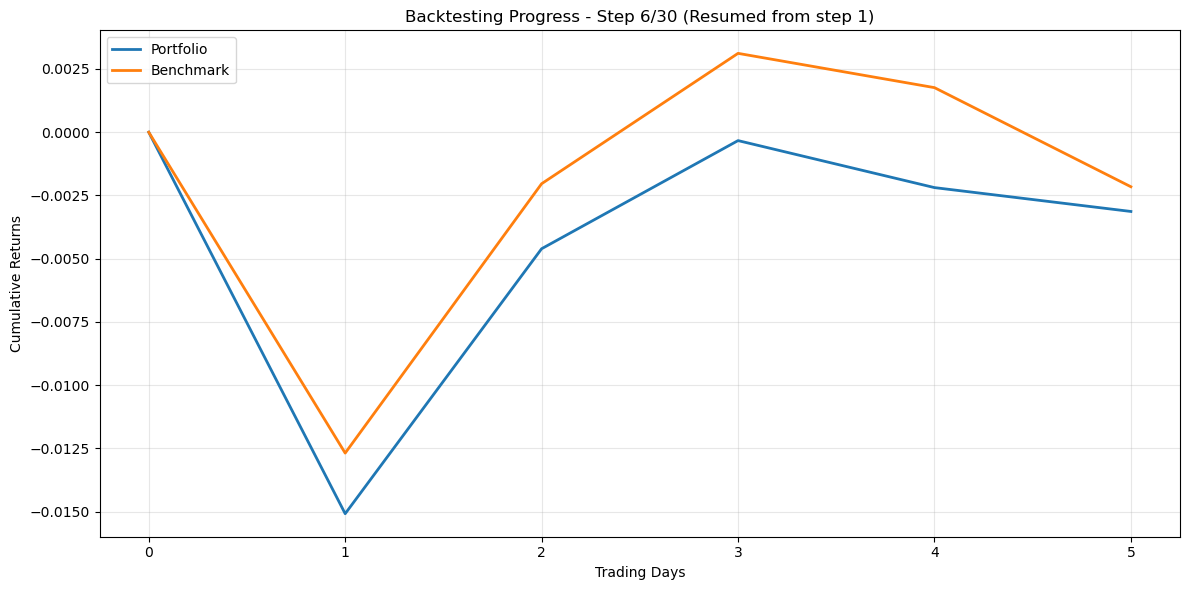

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_6.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2013-12-05 00:00:00 to 2014-01-21 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'C

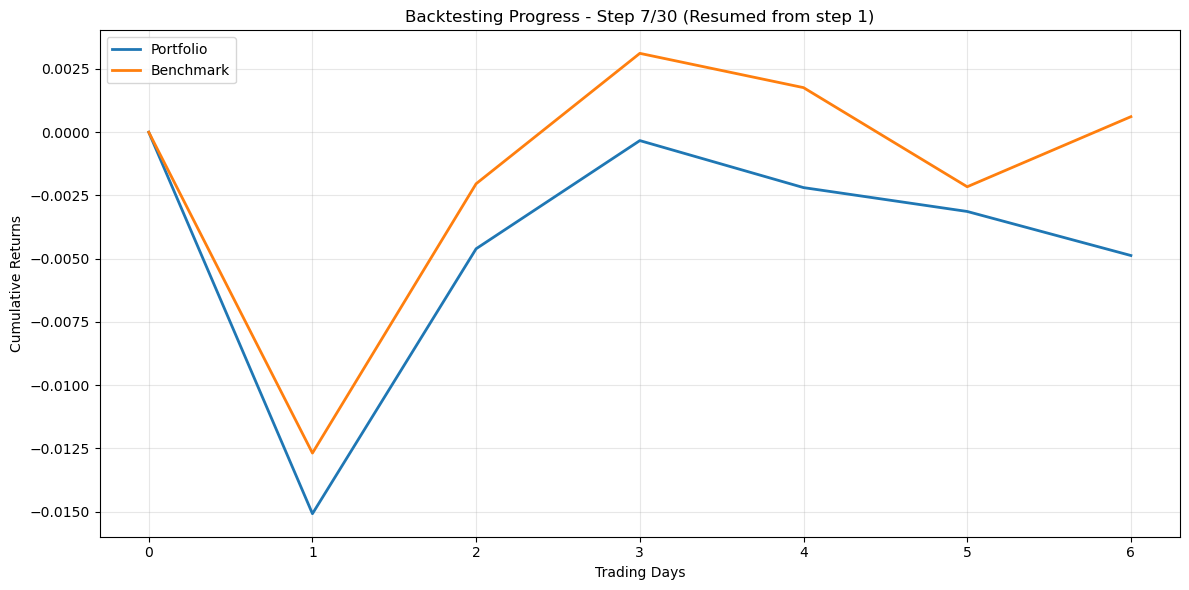

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_7.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2013-12-06 00:00:00 to 2014-01-22 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'C

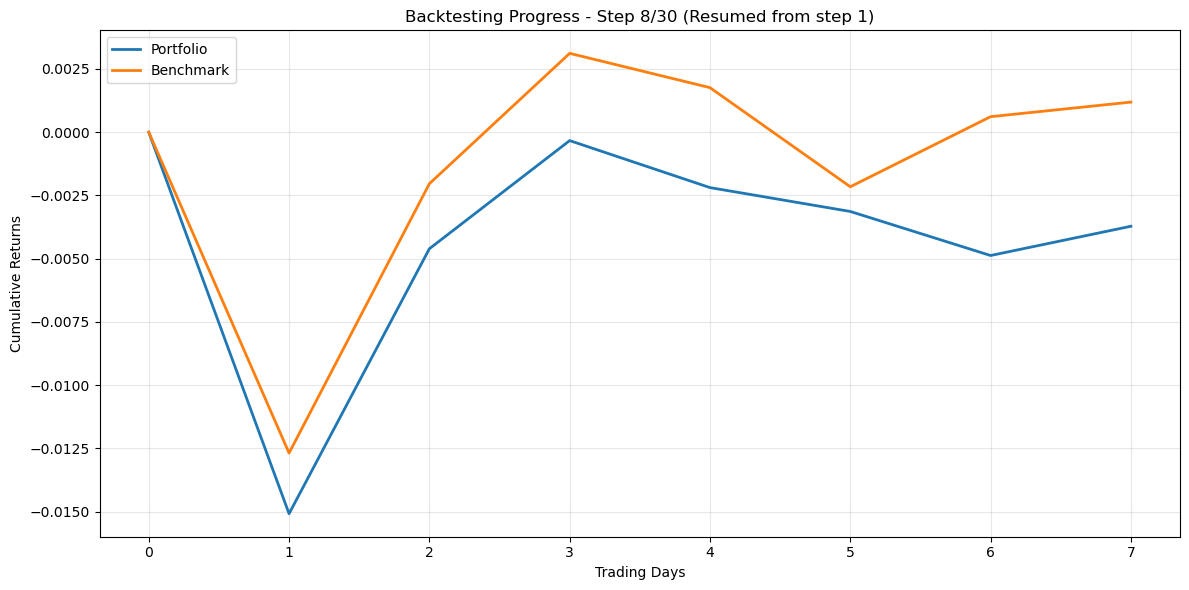

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_8.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2013-12-09 00:00:00 to 2014-01-23 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'C

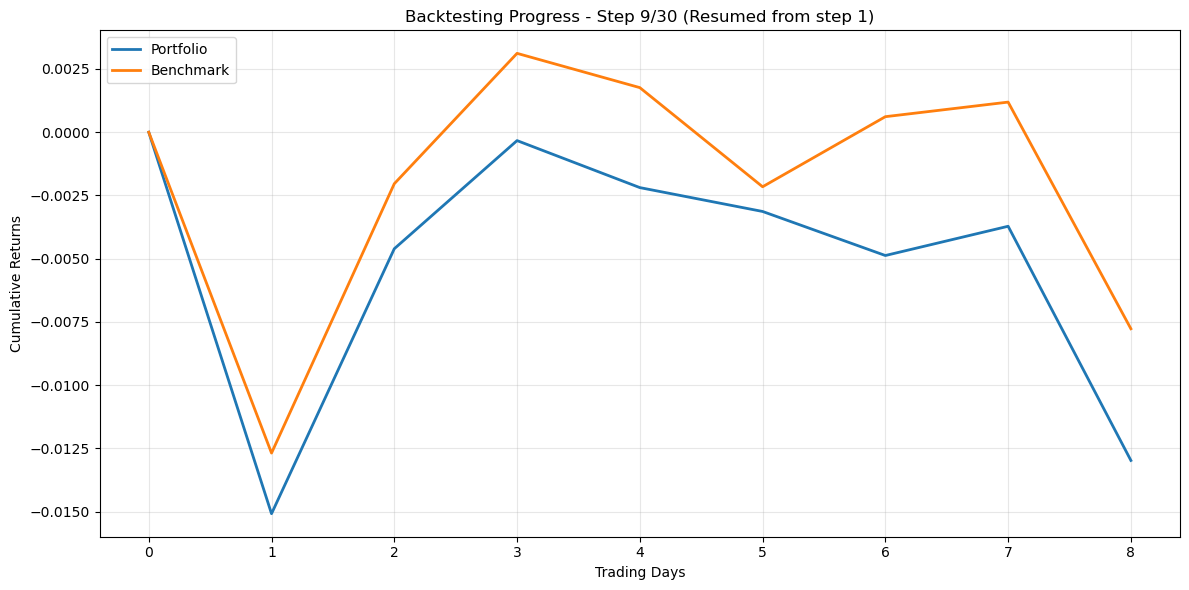

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_9.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2013-12-10 00:00:00 to 2014-01-24 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'C

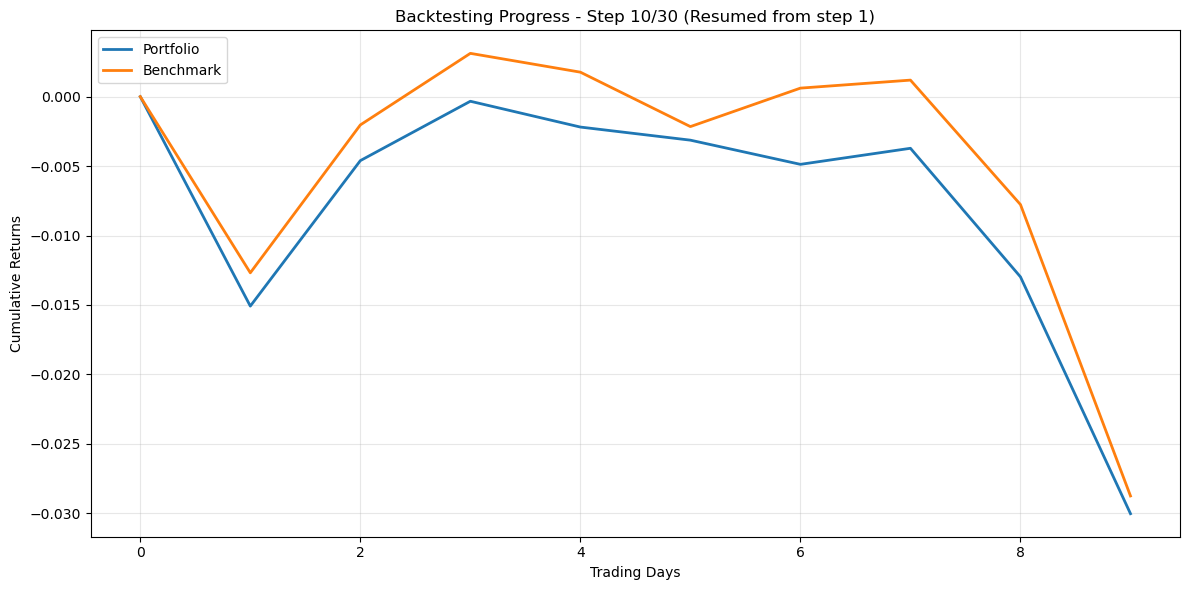

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_10.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2013-12-11 00:00:00 to 2014-01-27 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', '

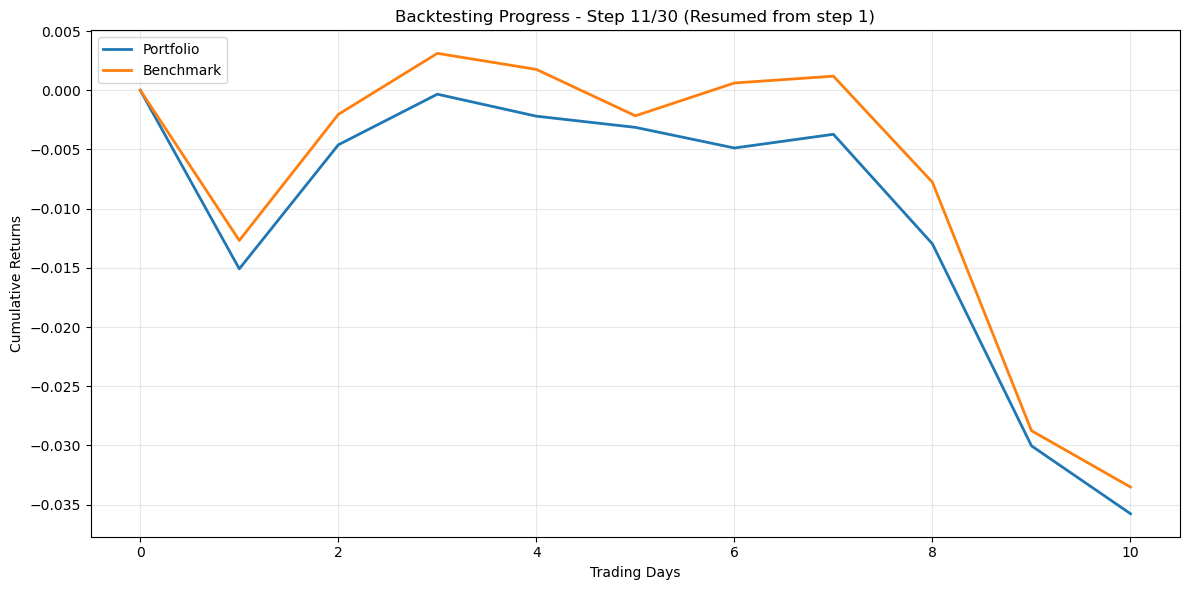

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_11.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2013-12-12 00:00:00 to 2014-01-28 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', '

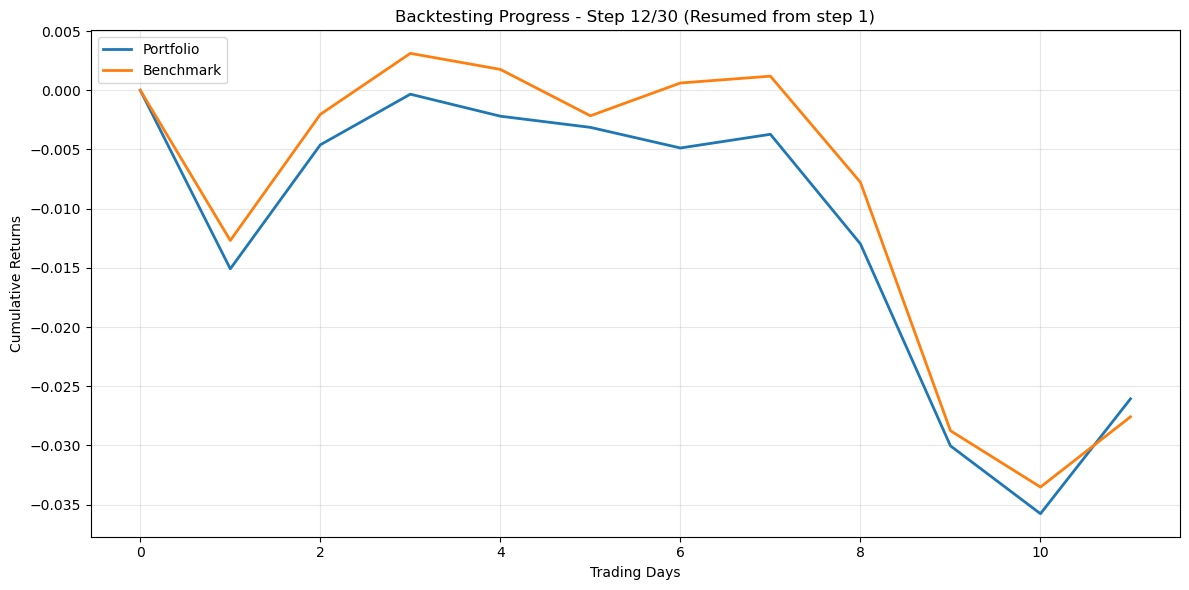

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_12.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2013-12-13 00:00:00 to 2014-01-29 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', '

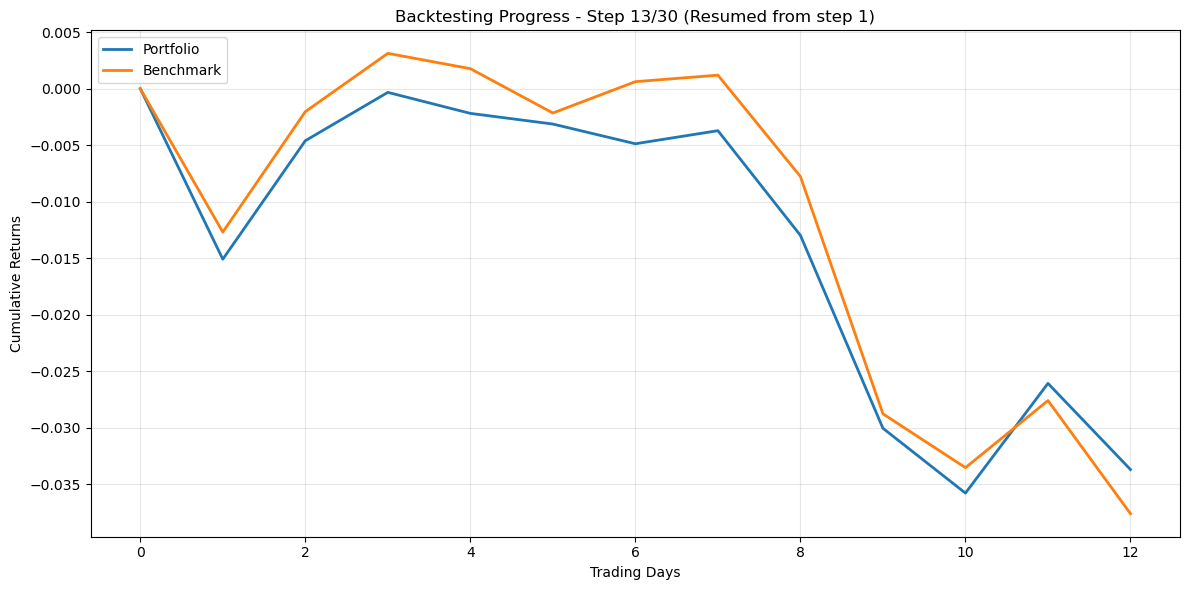

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_13.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2013-12-16 00:00:00 to 2014-01-30 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', '

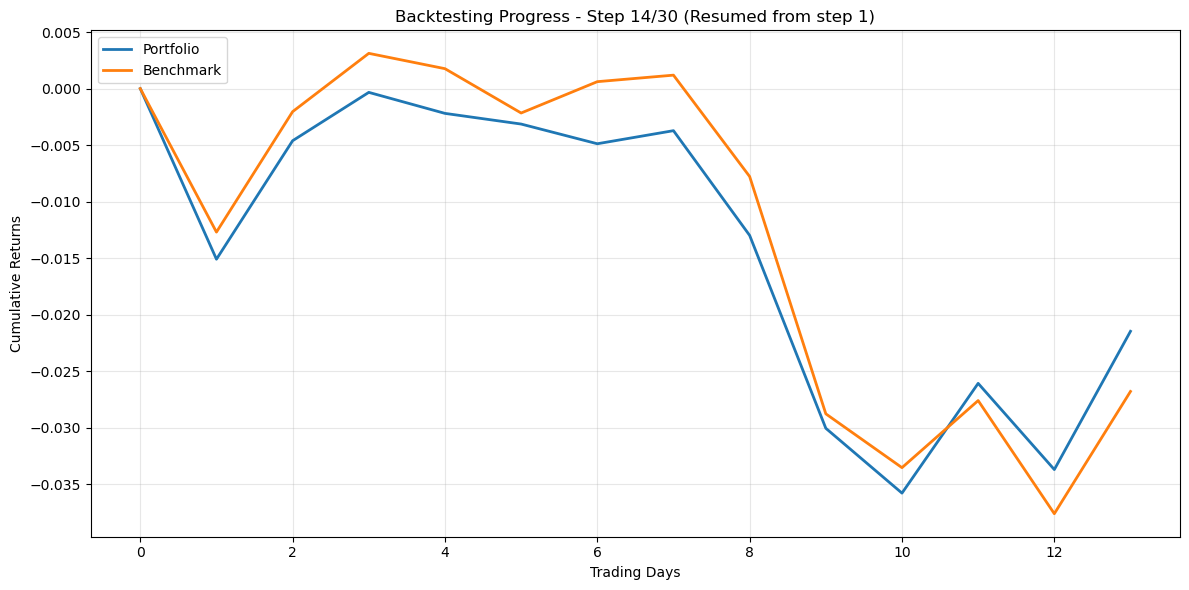

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_14.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2013-12-17 00:00:00 to 2014-01-31 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', '

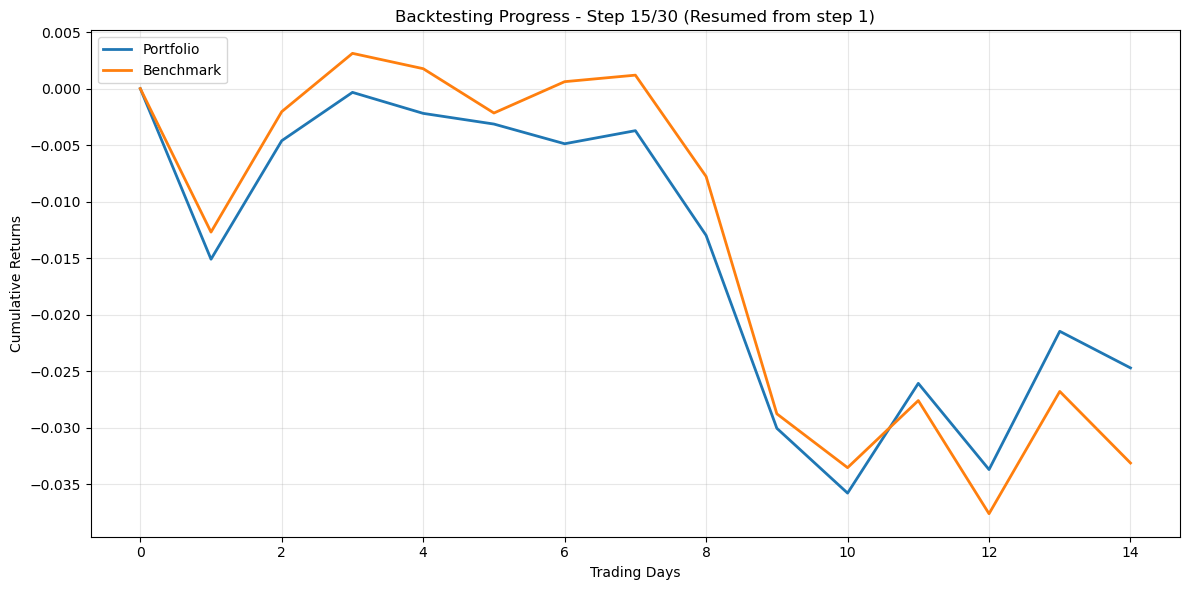

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_15.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2013-12-18 00:00:00 to 2014-02-03 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', '

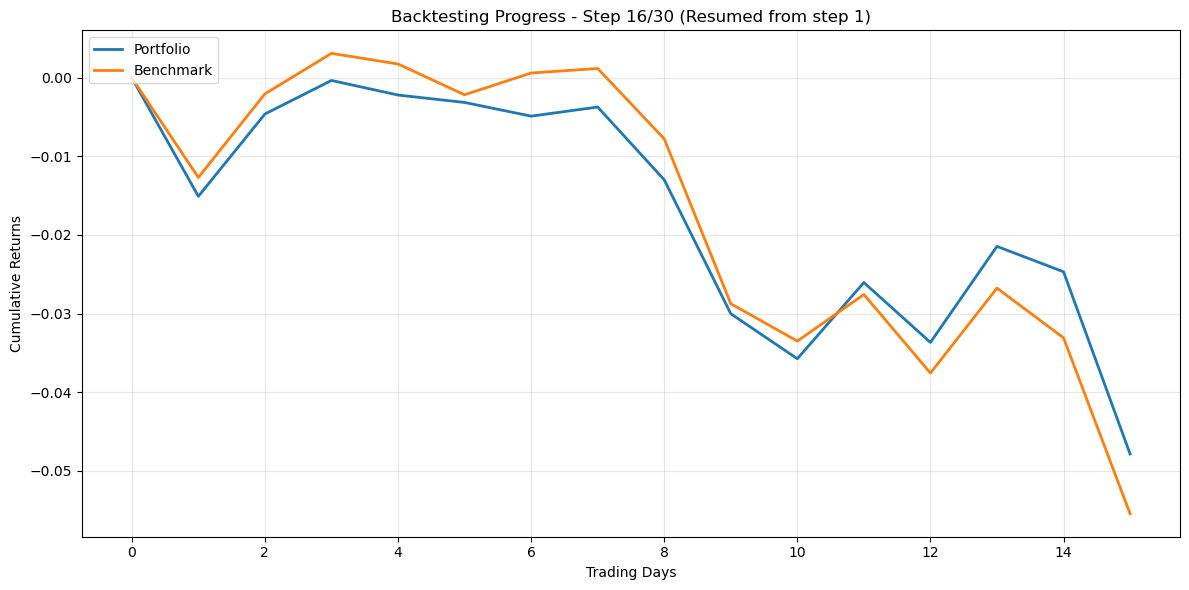

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_16.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2013-12-19 00:00:00 to 2014-02-04 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', '

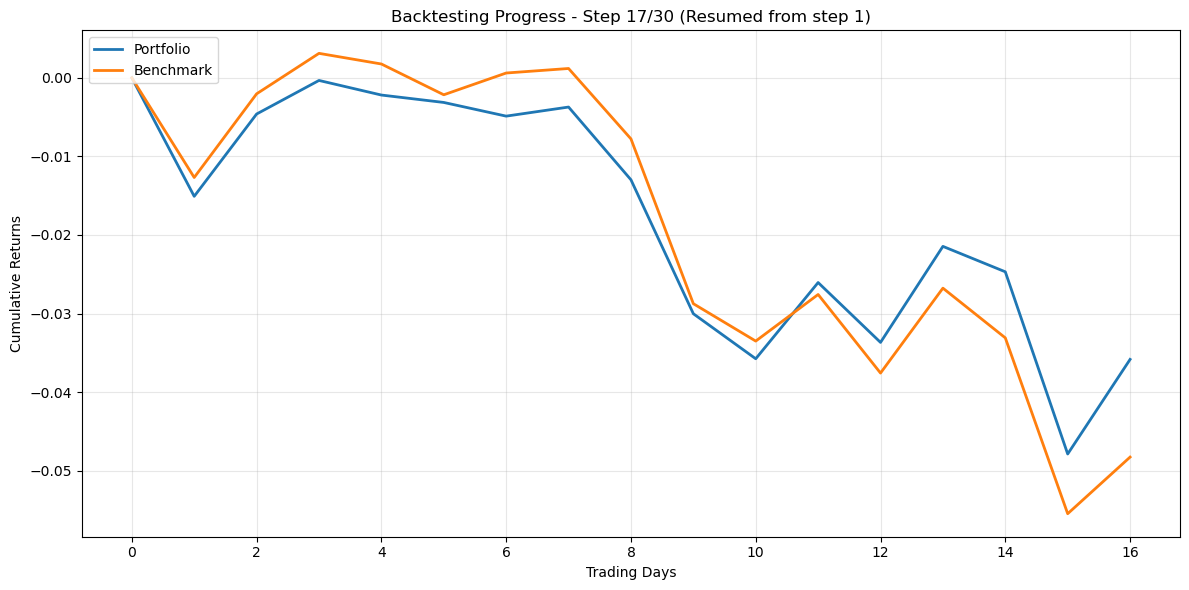

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_17.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2013-12-20 00:00:00 to 2014-02-05 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', '

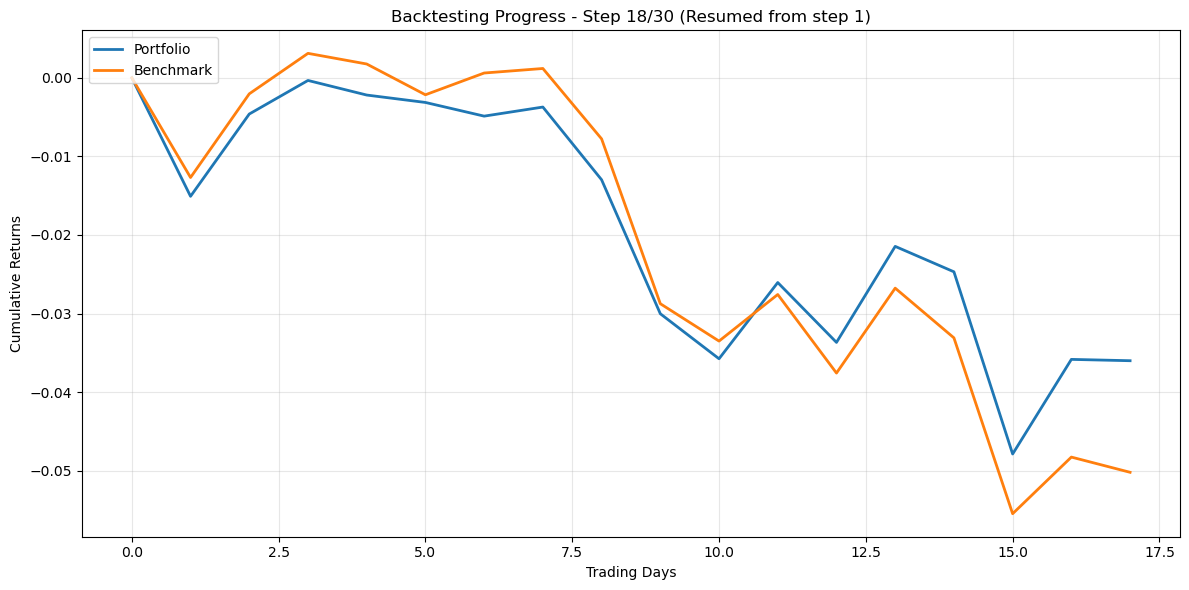

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_18.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2013-12-23 00:00:00 to 2014-02-06 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', '

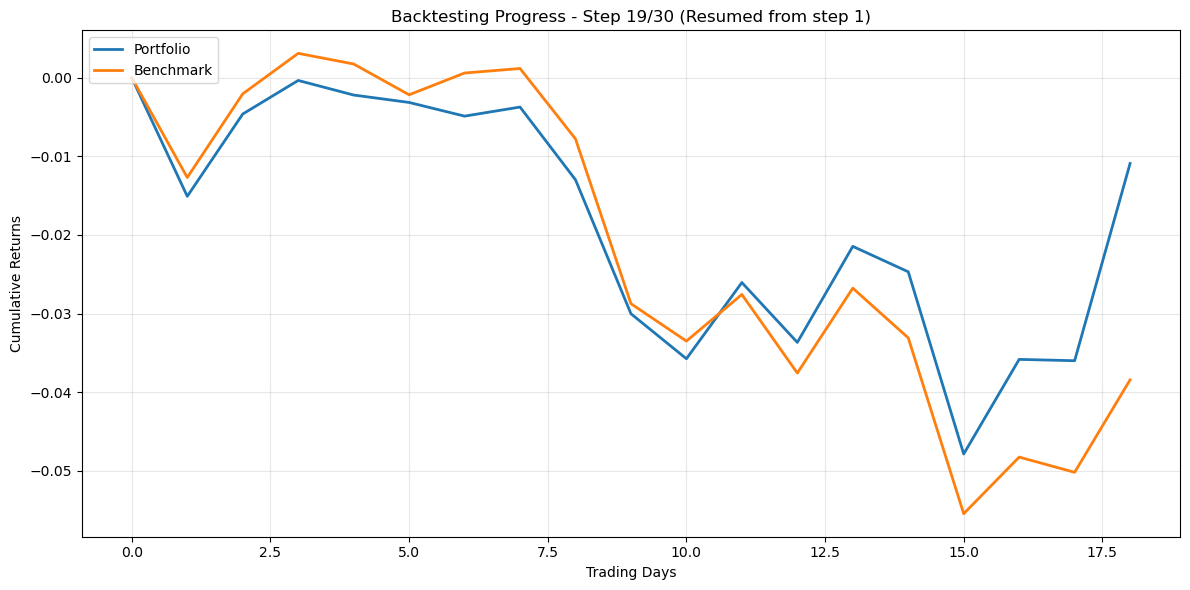

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_19.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2013-12-24 00:00:00 to 2014-02-07 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', '

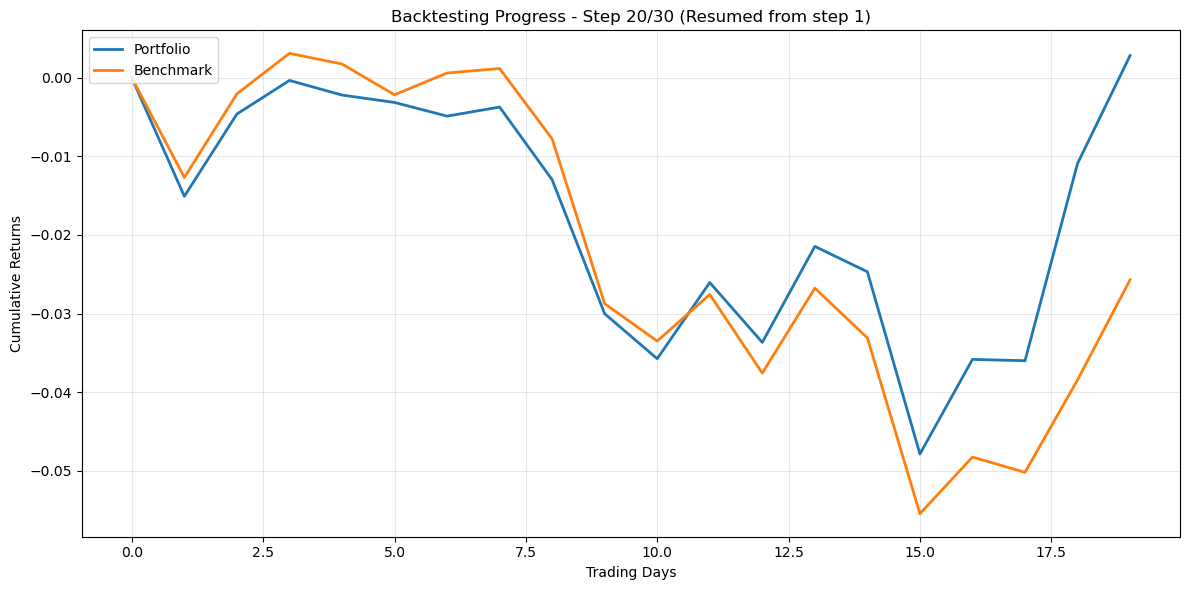

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_20.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2013-12-26 00:00:00 to 2014-02-10 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', '

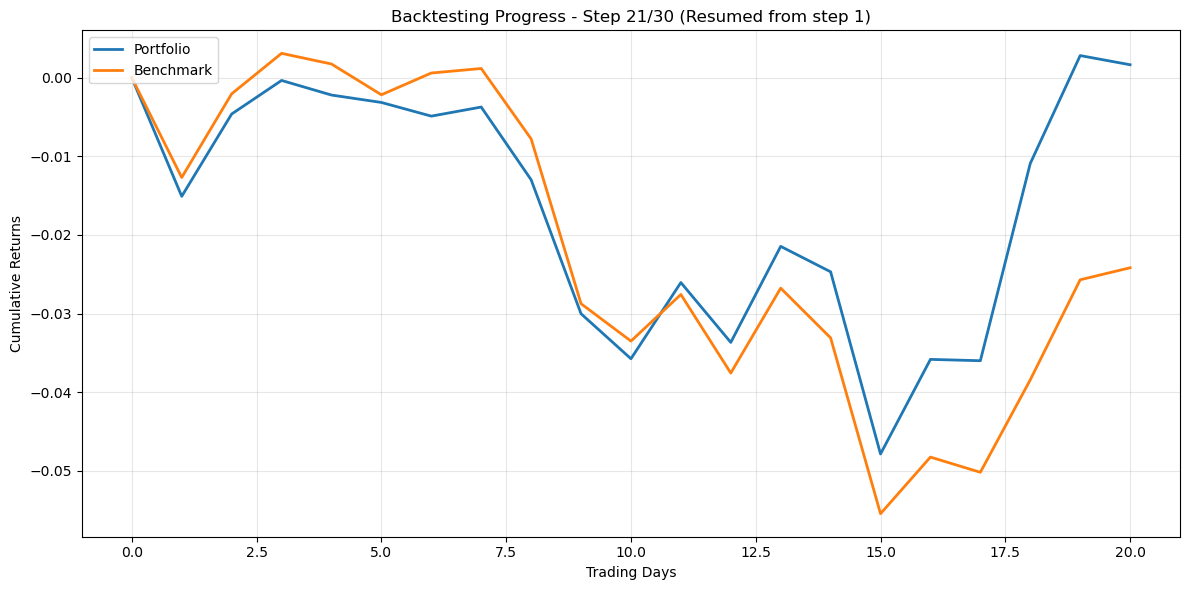

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_21.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2013-12-27 00:00:00 to 2014-02-11 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', '

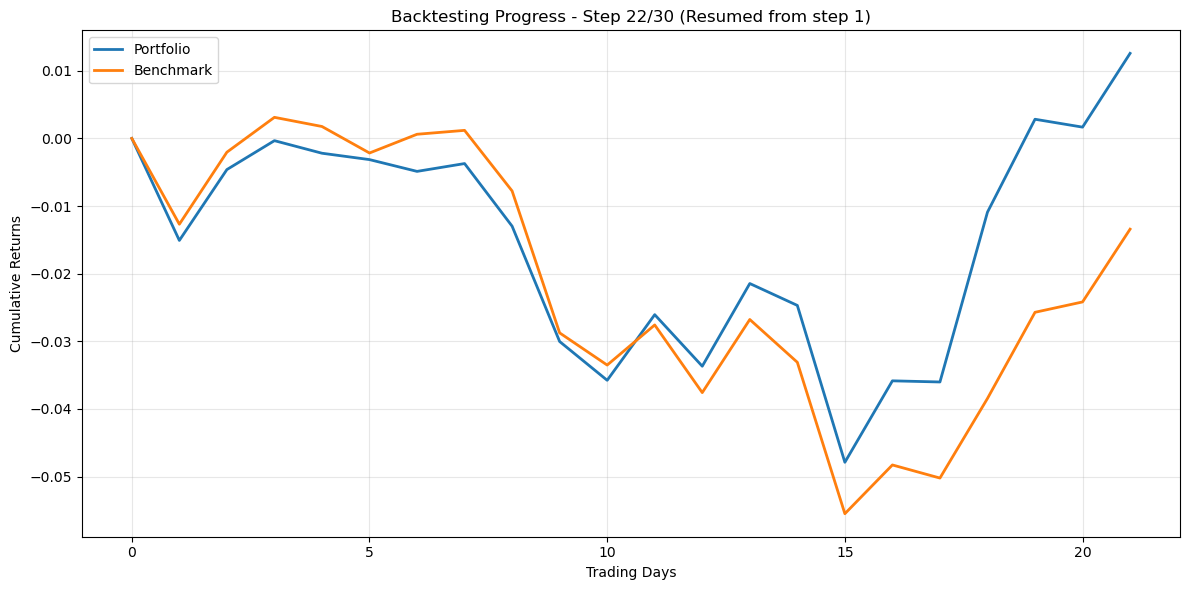

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_22.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2013-12-30 00:00:00 to 2014-02-12 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', '

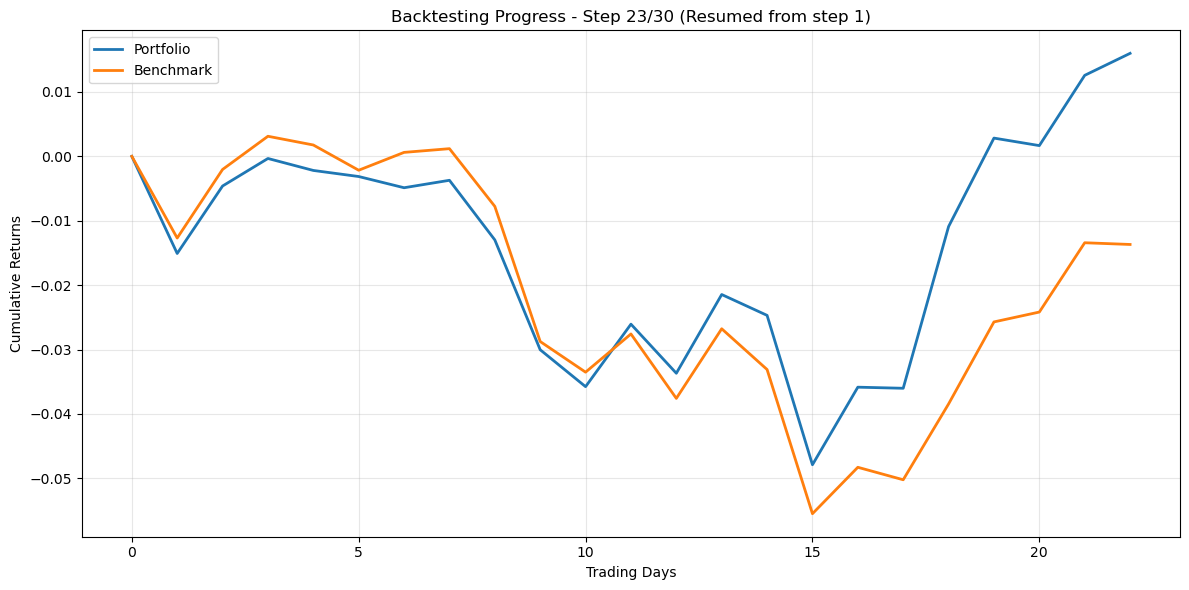

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_23.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2013-12-31 00:00:00 to 2014-02-13 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', '

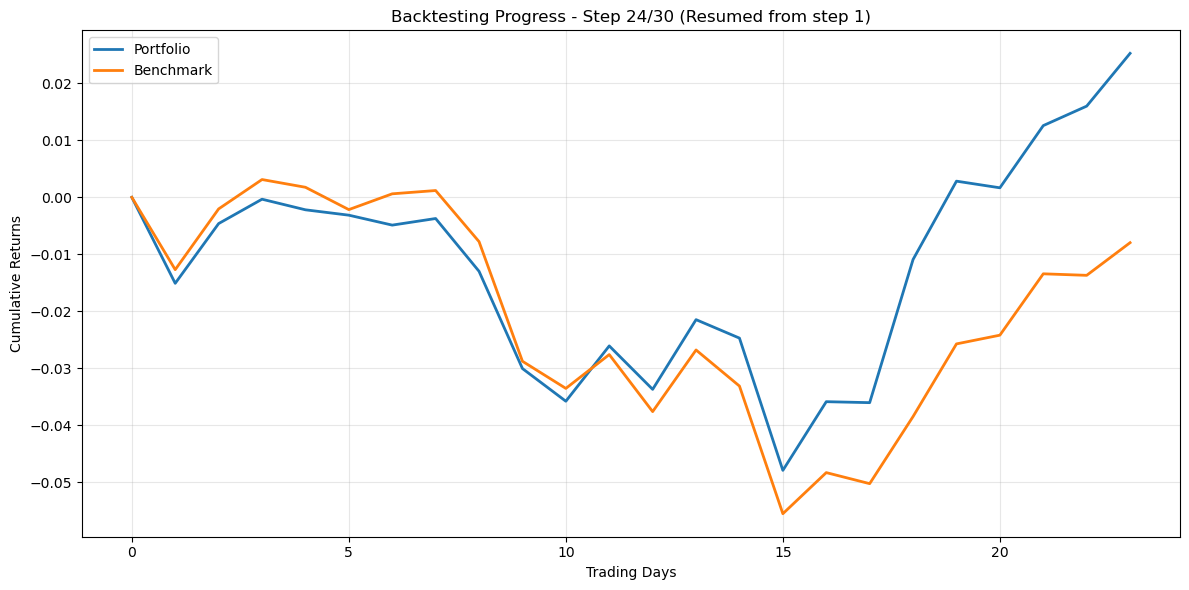

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_24.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2014-01-02 00:00:00 to 2014-02-14 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', '

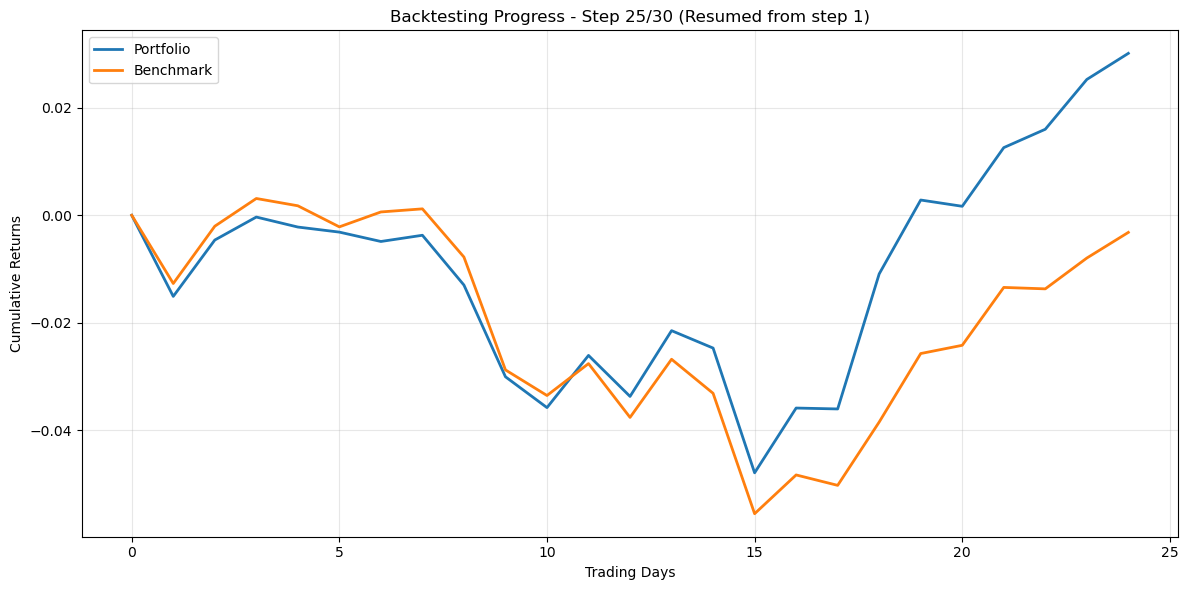

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_25.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2014-01-03 00:00:00 to 2014-02-18 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', '

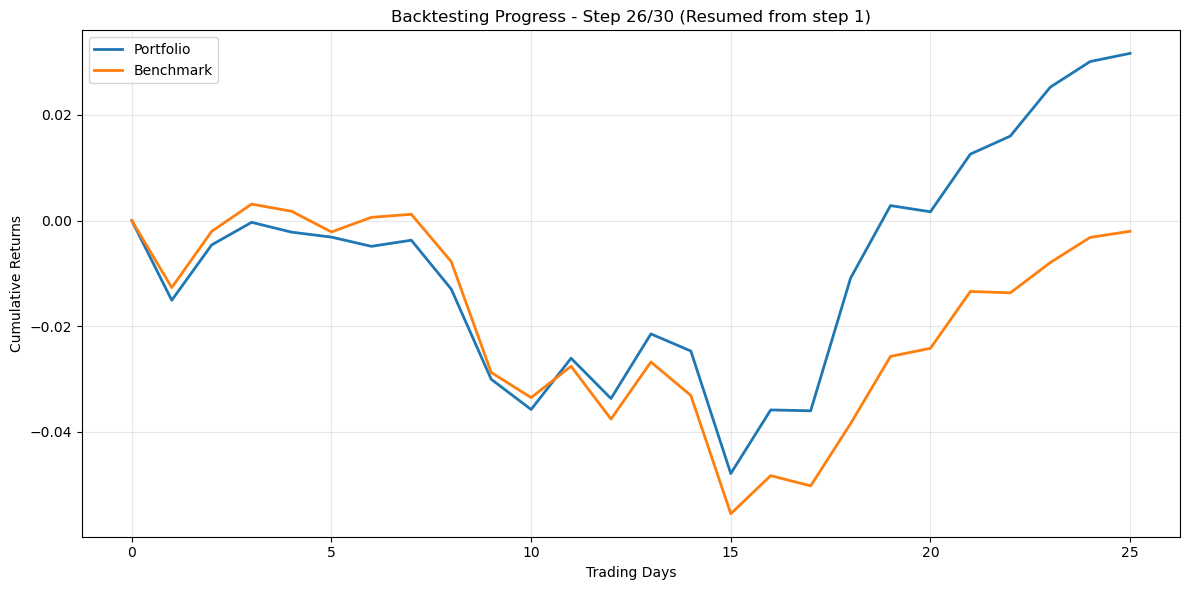

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_26.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2014-01-06 00:00:00 to 2014-02-19 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', '

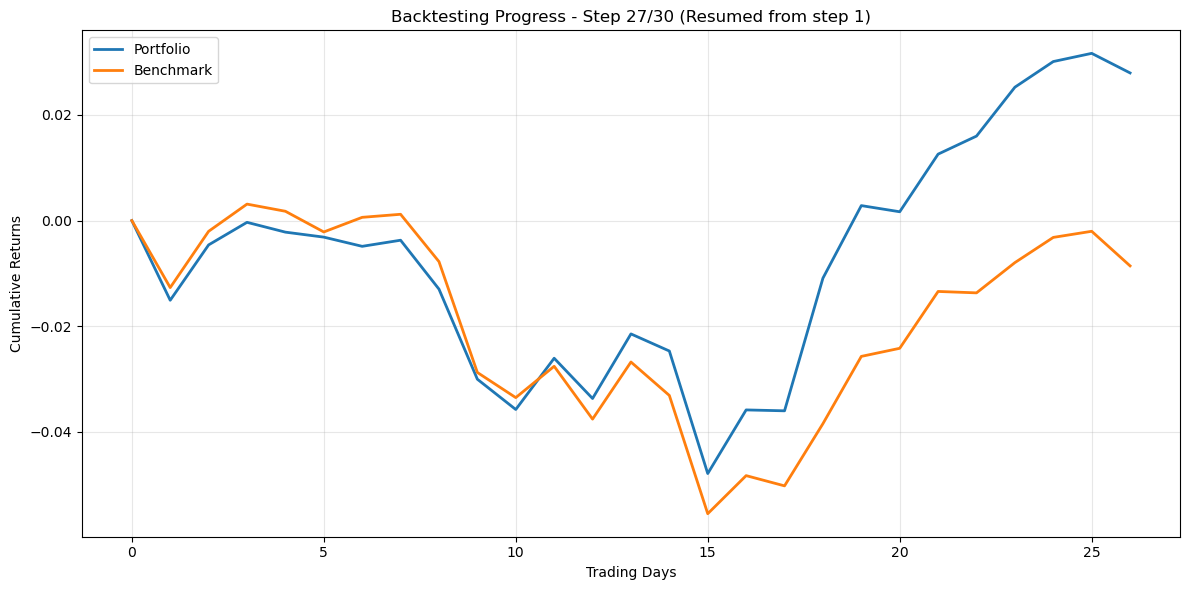

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_27.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2014-01-07 00:00:00 to 2014-02-20 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', '

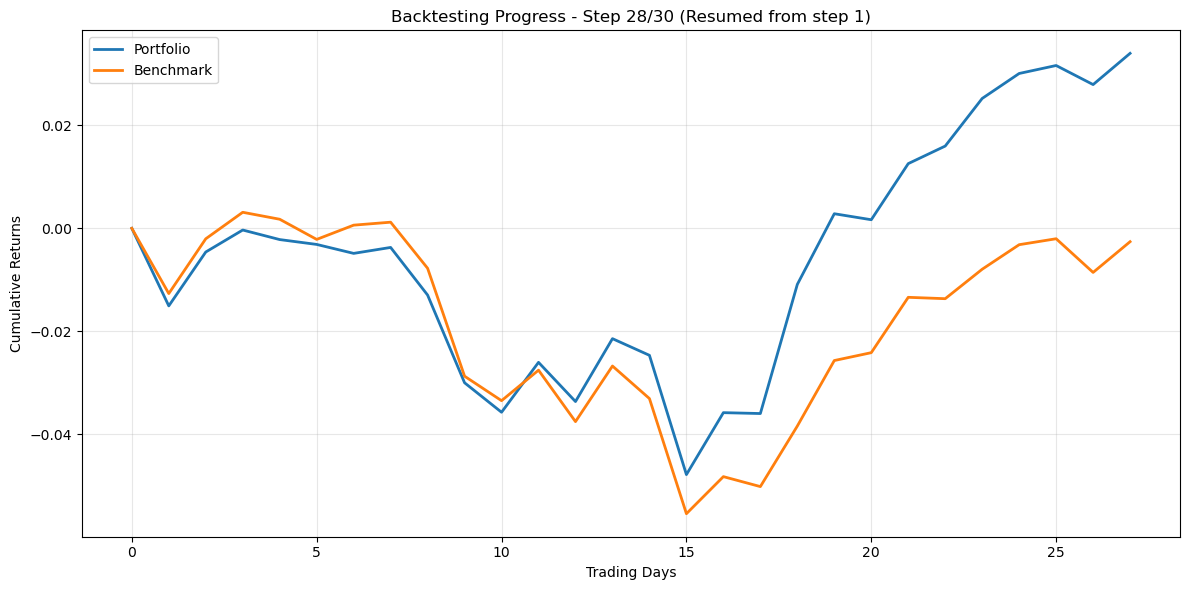

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_28.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2014-01-08 00:00:00 to 2014-02-21 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', '

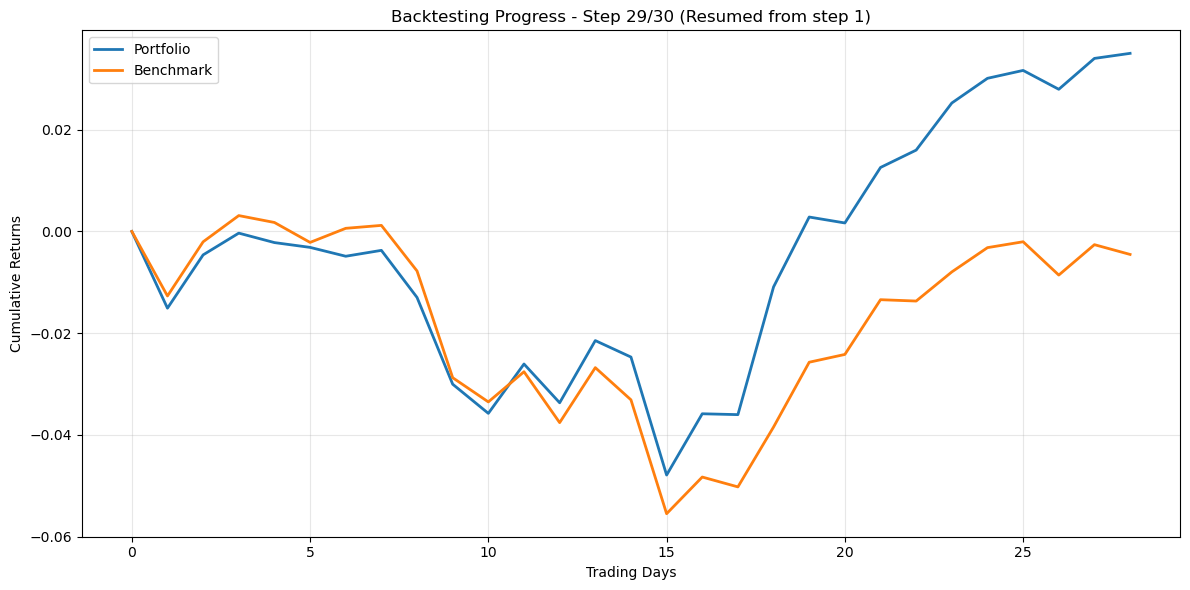

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_29.pkl

D-WAVE API CALL REQUEST
Dataset shape: (31, 680)
Number of assets: 680
Budget: $1,000,000
Min investment: 0.0001
Date range: 2014-01-09 00:00:00 to 2014-02-24 00:00:00
✓ API call approved. Proceeding with D-Wave optimization...
D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', '

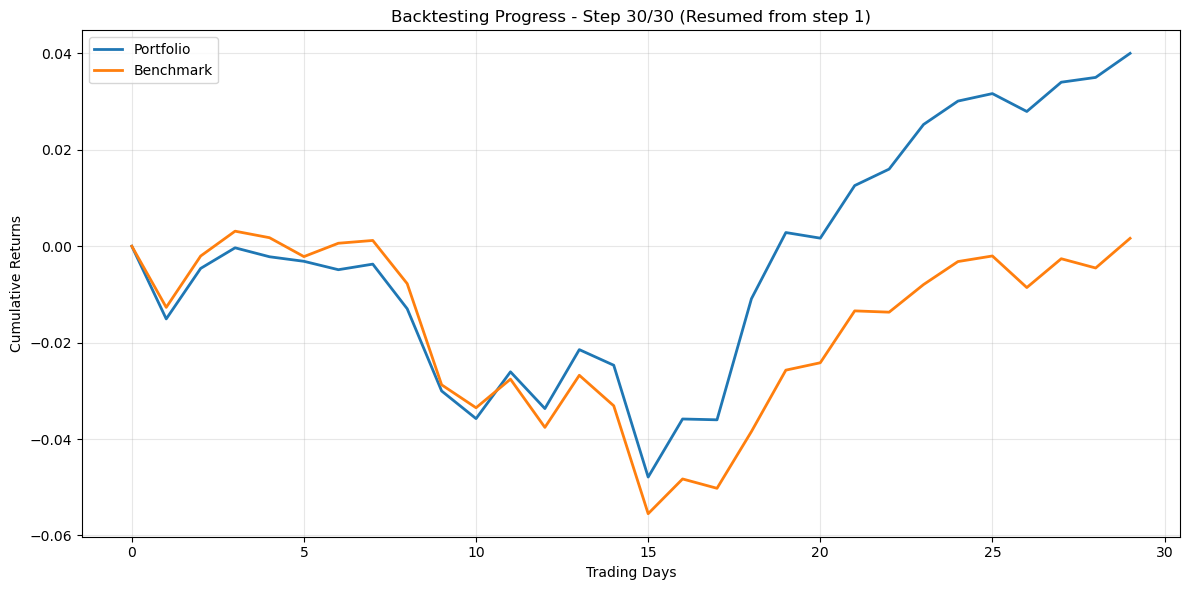

Dictionary pickled and saved to ../../results/sharpe_optimization/dwave_steps/period_0_step_30.pkl


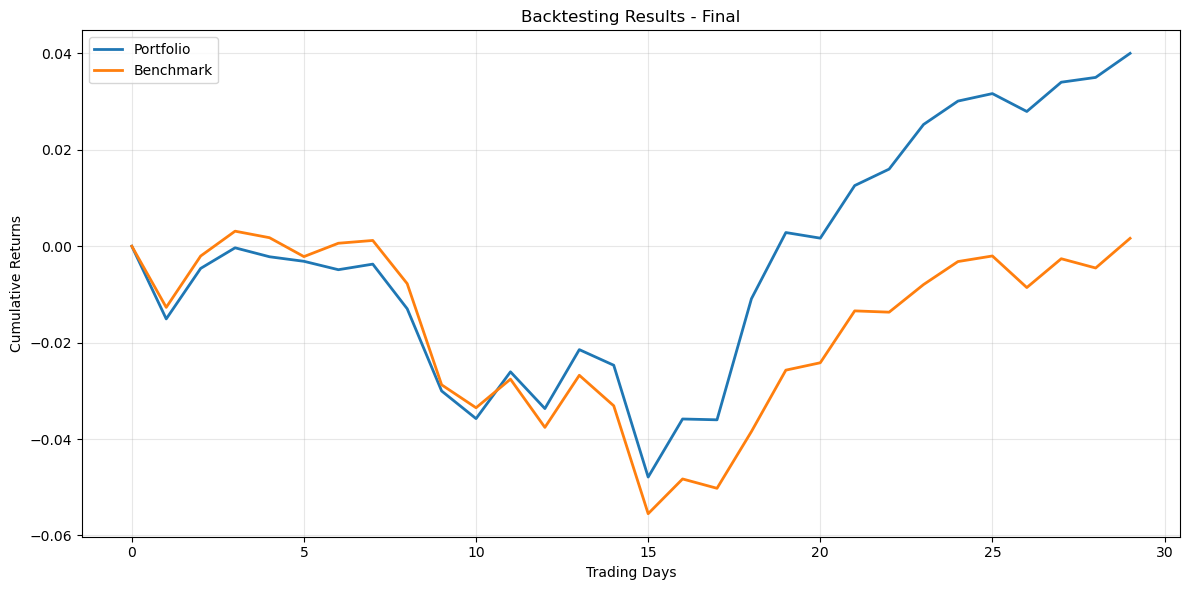

Dictionary pickled and saved to ../../results/sharpe_optimization/results_dwave-nl_0.pkl


In [17]:
results_path_cqm_wide = '../../results/sharpe_optimization/results_dwave-nl_{}.pkl'
_ = run_experiment(
    results_path_cqm_wide, 
    source_wide, 
    benchmark, 
    opt_fun_dwave, 
    parameters,
    checkpoint_base_dir='../../results/sharpe_optimization/dwave_steps',  # D-Wave-specific checkpoint directory
    force_resume=True  # Enable resume from checkpoints
)

#### Performance Analysis for Wide Dataset

In [18]:
# Performance analysis for CQM optimization (Wide Dataset - Stocks + ETFs)
cqm_wide_solvers = [
    {'path_template': '../../results/sharpe_optimization/results_dwave-nl_{}.pkl', 'name': 'D-Wave CQM Sharpe'},
]

print("\n" + "="*100)
print("COMPREHENSIVE PERFORMANCE SUMMARY - D-Wave CQM Optimization (Wide Dataset - Stocks + ETFs)")
print("="*100)
summary_df = performance_summary(cqm_wide_solvers, n_periods)
if not summary_df.empty:
    display(summary_df)
    
    # Performance analysis
    print("\nPerformance Analysis:")
    print("-" * 50)
    print(f"Successful periods: {summary_df.iloc[0]['Periods']}/{n_periods}")
    print(f"Average return: {summary_df.iloc[0]['Avg_Return']:.4f}")
    print(f"Average execution time: {summary_df.iloc[0]['Avg_Time']:.2f}s")
    print(f"Success rate: {summary_df.iloc[0]['Success_Rate']:.1f}%")
else:
    print("No summary data available")


COMPREHENSIVE PERFORMANCE SUMMARY - D-Wave CQM Optimization (Wide Dataset - Stocks + ETFs)


,Solver,Periods,Avg_Return,Std_Return,Min_Return,Max_Return,Avg_Time,Std_Time,Success_Rate
0,D-Wave CQM Sharpe,1,0.04,0.0,0.04,0.04,6732.3263,0.0,100.0



Performance Analysis:
--------------------------------------------------
Successful periods: 1/1
Average return: 0.0400
Average execution time: 6732.33s
Success rate: 100.0%



Creating average weight distribution plot...
Total assets: 680
Assets with weight > 0.0001: 680
Sum of significant weights: 1.0000


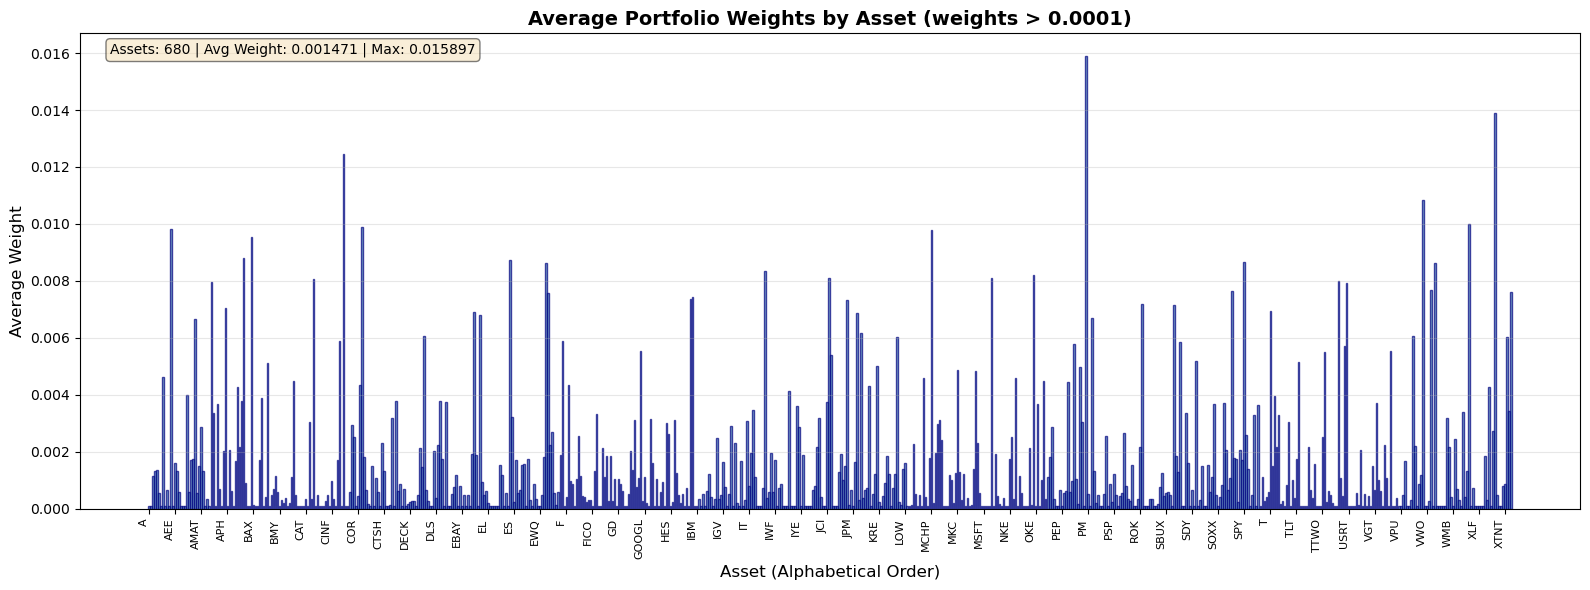


Top 10 Assets by Average Weight:
--------------------------------------------------
 1. PLD       : 0.015897 (1.5897%)
 2. XOM       : 0.013897 (1.3897%)
 3. CMI       : 0.012464 (1.2464%)
 4. VUG       : 0.010857 (1.0857%)
 5. XEL       : 0.009982 (0.9982%)
 6. CPAY      : 0.009906 (0.9906%)
 7. ADP       : 0.009823 (0.9823%)
 8. MCHP      : 0.009797 (0.9797%)
 9. BALL      : 0.009557 (0.9557%)
10. AXP       : 0.008792 (0.8792%)



In [ ]:
# Plot average weight distribution by asset (alphabetical order)
results_path_wide = results_path_cqm_wide.format(0)
if os.path.exists(results_path_wide):
    print("\nCreating average weight distribution plot...")
    results = read_pickle_dict(results_path_wide)
    
    weights_history = results.get('weights_history')
    
    if weights_history is not None and not weights_history.empty:
        # Calculate average weights across all time periods
        avg_weights = weights_history.mean(axis=0).sort_index()
        
        # Filter out near-zero weights for better visualization
        threshold = 0.0001
        significant_weights = avg_weights[avg_weights > threshold]
        
        print(f"Total assets: {len(avg_weights)}")
        print(f"Assets with weight > {threshold}: {len(significant_weights)}")
        print(f"Sum of significant weights: {significant_weights.sum():.4f}")
        
        # Create bar plot
        fig, ax = plt.subplots(figsize=(16, 6))
        
        x_pos = np.arange(len(significant_weights))
        bars = ax.bar(x_pos, significant_weights.values, color='steelblue', alpha=0.7, edgecolor='navy')
        
        # Set x-axis labels with reduced frequency to avoid clutter
        n_labels = min(50, len(significant_weights))  # Show max 50 labels
        step = max(1, len(significant_weights) // n_labels)
        ax.set_xticks(x_pos[::step])
        ax.set_xticklabels(significant_weights.index[::step], rotation=90, ha='right', fontsize=8)
        
        ax.set_xlabel('Asset (Alphabetical Order)', fontsize=12)
        ax.set_ylabel('Average Weight', fontsize=12)
        ax.set_title(f'Average Portfolio Weights by Asset (weights > {threshold})', fontsize=14, fontweight='bold')
        ax.grid(True, axis='y', alpha=0.3)
        
        # Add statistics text
        stats_text = f'Assets: {len(significant_weights)} | Avg Weight: {significant_weights.mean():.6f} | Max: {significant_weights.max():.6f}'
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        plt.show()
        
        # Print top 10 weighted assets
        print("\nTop 10 Assets by Average Weight:")
        print("-" * 50)
        top_10 = avg_weights.sort_values(ascending=False).head(10)
        for i, (asset, weight) in enumerate(top_10.items(), 1):
            print(f"{i:2d}. {asset:10s}: {weight:.6f} ({weight*100:.4f}%)")
        
        print("\n" + "="*80)
    else:
        print("No weights_history data available in results")
else:
    print(f"Results file not found: {results_path_wide}")

## D-Wave vs Classical Solvers - Trace Comparison

Compare the portfolio performance trace of D-Wave CQM against classical solvers for the same period.

Discovering all available time periods...
✓ Found D-Wave results for 1 period(s): [0]
  Period 0: Loaded 5 solver(s)

PERIOD 0 - COMPARATIVE ANALYSIS


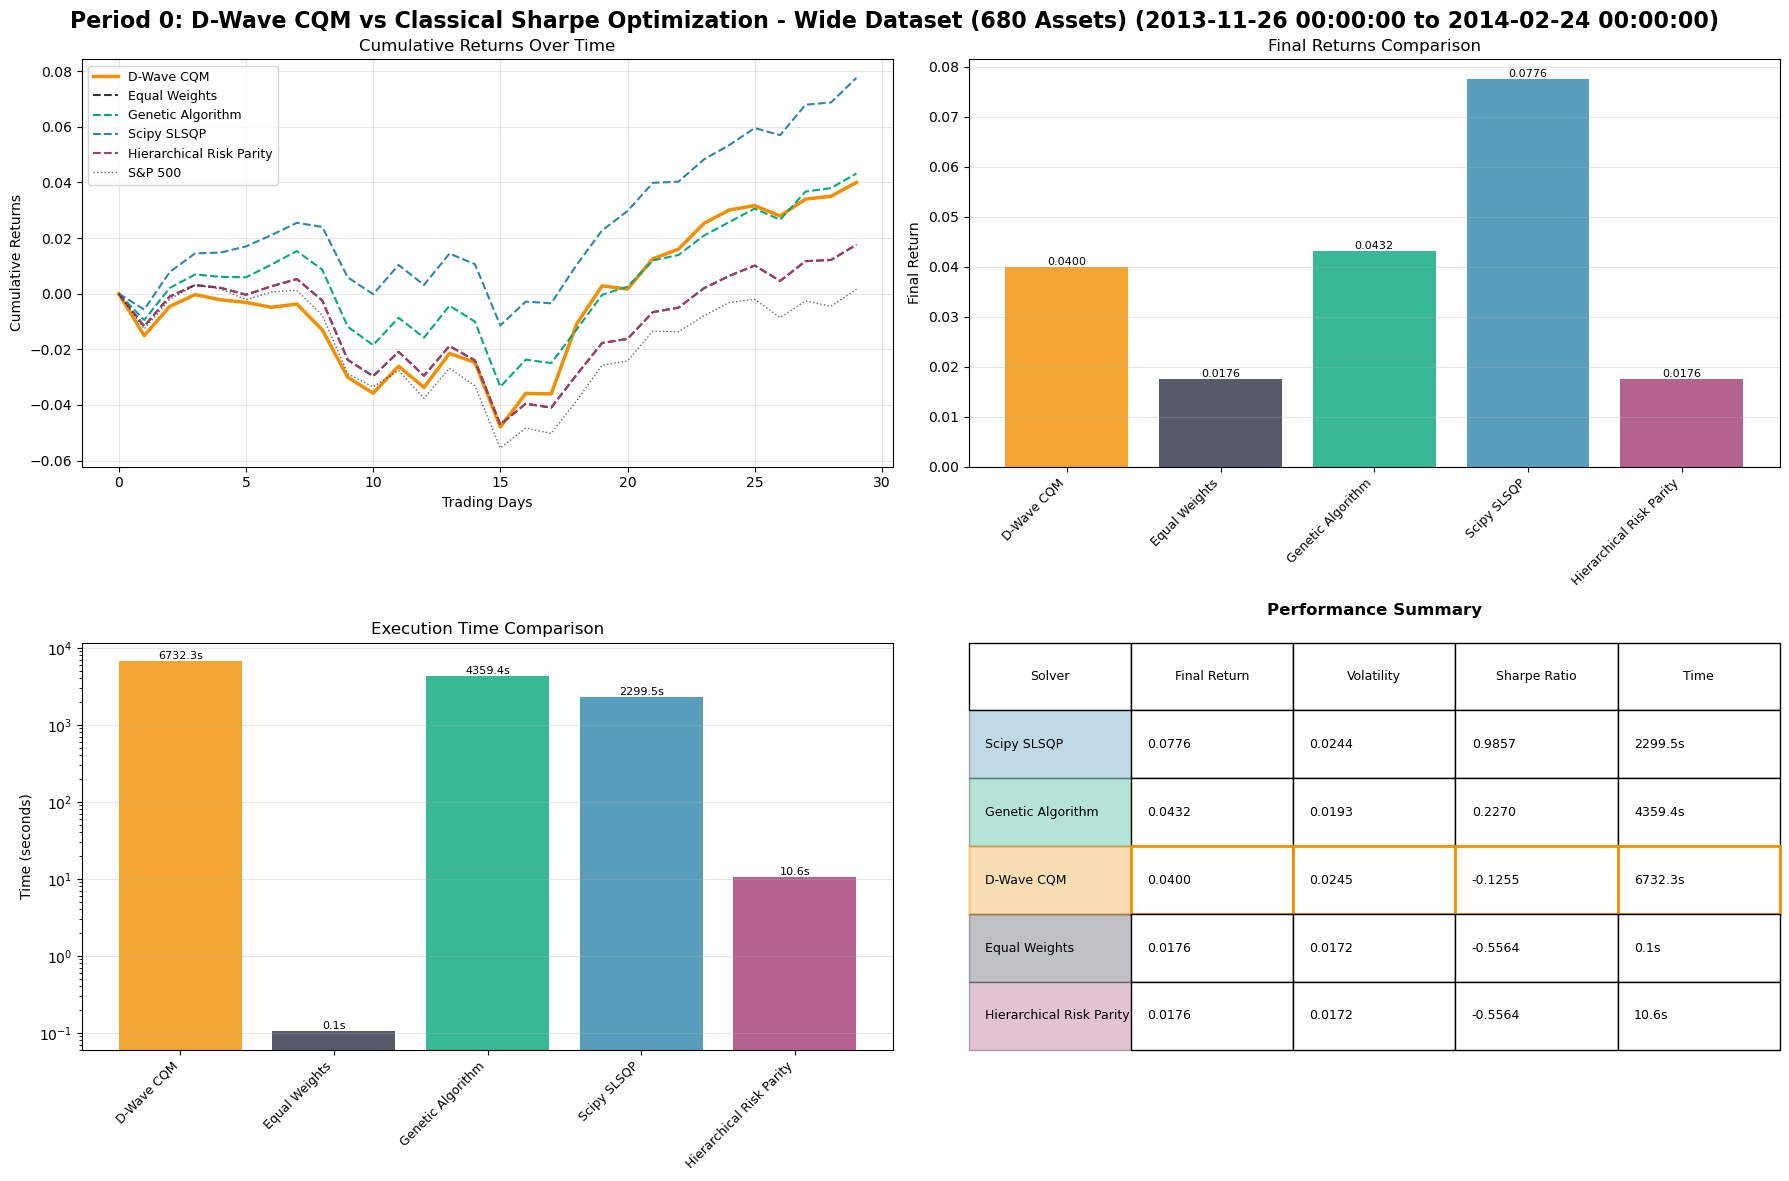


DETAILED PERFORMANCE COMPARISON - Period 0
----------------------------------------------------------------------------------------------------

D-Wave CQM Quantum Solver:
  Final Return: 0.0400 (4.00%)
  Execution Time: 6732.33s

Comparison with Classical Solvers:

  vs Equal Weights:
    Return Difference: +0.0224 (+127.16%)
    Time Ratio: 64546.47x slower

  vs Genetic Algorithm:
    Return Difference: -0.0032 (-7.45%)
    Time Ratio: 1.54x slower

  vs Scipy SLSQP:
    Return Difference: -0.0376 (-48.44%)
    Time Ratio: 2.93x slower

  vs Hierarchical Risk Parity:
    Return Difference: +0.0224 (+127.16%)
    Time Ratio: 637.37x slower



In [21]:
# Load all available results across all time periods (comparison only - no new simulations)
print("Discovering all available time periods...")
print("="*100)

import glob
import re

results_base_dir = '../../results/sharpe_optimization/'

# Find all D-Wave results to determine available periods
dwave_pattern = os.path.join(results_base_dir, 'results_dwave-nl_*.pkl')
dwave_files = glob.glob(dwave_pattern)

# Extract period numbers from D-Wave results
available_periods = []
for f in dwave_files:
    match = re.search(r'results_dwave-nl_(\d+)\.pkl$', f)
    if match:
        available_periods.append(int(match.group(1)))

available_periods.sort()

if len(available_periods) == 0:
    print("✗ No D-Wave results found. Run the D-Wave optimization first.")
else:
    print(f"✓ Found D-Wave results for {len(available_periods)} period(s): {available_periods}")
    
    # Load results for all available periods
    all_periods_data = {}
    
    for period in available_periods:
        period_data = {}
        
        # Load D-Wave results
        dwave_path = f'../../results/sharpe_optimization/results_dwave-nl_{period}.pkl'
        if os.path.exists(dwave_path):
            period_data['D-Wave CQM'] = read_pickle_dict(dwave_path)
        
        # Load classical solver results
        solver_prefixes = {
            'Equal Weights': 'ew',
            'Genetic Algorithm': 'ga',
            'Scipy SLSQP': 'bf',
            'Hierarchical Risk Parity': 'hrp',
        }
        
        for solver_name, prefix in solver_prefixes.items():
            path = f'../../results/sharpe_optimization/results_{prefix}_{period}.pkl'
            if os.path.exists(path):
                period_data[solver_name] = read_pickle_dict(path)
        
        all_periods_data[period] = period_data
        print(f"  Period {period}: Loaded {len(period_data)} solver(s)")
    
    print("="*100)
    
    # Create comprehensive visualization for each period
    for period in available_periods:
        results_dict = all_periods_data[period]
        
        if len(results_dict) == 0:
            print(f"\n⚠️  No results available for period {period}")
            continue
        
        print(f"\n{'='*100}")
        print(f"PERIOD {period} - COMPARATIVE ANALYSIS")
        print(f"{'='*100}")
        
        # Get D-Wave results for this period
        dwave_results = results_dict.get('D-Wave CQM', None)
        
        # Extract date range from results
        date_range = ""
        if dwave_results:
            start_date = dwave_results.get('start_date', 'N/A')
            end_date = dwave_results.get('end_date', 'N/A')
            date_range = f" ({start_date} to {end_date})"
        
        fig, axes = plt.subplots(2, 2, figsize=(18, 12))
        fig.suptitle(f'Period {period}: D-Wave CQM vs Classical Sharpe Optimization - Wide Dataset (680 Assets){date_range}', 
                     fontsize=16, fontweight='bold')
        
        # Define color scheme
        colors = {
            'D-Wave CQM': '#F18F01',
            'Equal Weights': '#2D3142',
            'Genetic Algorithm': '#06A77D',
            'Scipy SLSQP': '#2E86AB',
            'Hierarchical Risk Parity': '#A23B72'
        }
        
        # Plot 1: Cumulative Returns Comparison
        ax1 = axes[0, 0]
        for solver_name, results in results_dict.items():
            portfolio_returns = results.get('portfolio_cumulative_returns', [])
            if len(portfolio_returns) > 0:
                color = colors.get(solver_name, '#333333')
                linewidth = 2.5 if solver_name == 'D-Wave CQM' else 1.5
                linestyle = '-' if solver_name == 'D-Wave CQM' else '--'
                ax1.plot(portfolio_returns, label=solver_name, 
                        color=color, linewidth=linewidth, linestyle=linestyle)
        
        # Add benchmark
        if dwave_results:
            benchmark_returns = dwave_results.get('benchmark_cumulative_returns', [])
            if len(benchmark_returns) > 0:
                ax1.plot(benchmark_returns, label='S&P 500', 
                        color='black', linewidth=1, linestyle=':', alpha=0.6)
        
        ax1.set_xlabel('Trading Days')
        ax1.set_ylabel('Cumulative Returns')
        ax1.set_title('Cumulative Returns Over Time')
        ax1.legend(loc='best', fontsize=9)
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Final Returns Bar Chart
        ax2 = axes[0, 1]
        final_returns = []
        solver_names = []
        bar_colors = []
        
        for solver_name, results in results_dict.items():
            portfolio_returns = results.get('portfolio_cumulative_returns', [])
            if len(portfolio_returns) > 0:
                final_returns.append(portfolio_returns[-1])
                solver_names.append(solver_name)
                bar_colors.append(colors.get(solver_name, '#333333'))
        
        bars = ax2.bar(range(len(final_returns)), final_returns, color=bar_colors, alpha=0.8)
        ax2.set_xticks(range(len(solver_names)))
        ax2.set_xticklabels(solver_names, rotation=45, ha='right', fontsize=9)
        ax2.set_ylabel('Final Return')
        ax2.set_title('Final Returns Comparison')
        ax2.grid(True, axis='y', alpha=0.3)
        
        # Add value labels on bars
        for i, (bar, value) in enumerate(zip(bars, final_returns)):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{value:.4f}', ha='center', va='bottom', fontsize=8)
        
        # Plot 3: Execution Time Comparison
        ax3 = axes[1, 0]
        exec_times = []
        time_solver_names = []
        time_colors = []
        
        for solver_name, results in results_dict.items():
            exec_time = results.get('total_run_time', 0)
            exec_times.append(exec_time)
            time_solver_names.append(solver_name)
            time_colors.append(colors.get(solver_name, '#333333'))
        
        bars = ax3.bar(range(len(exec_times)), exec_times, color=time_colors, alpha=0.8)
        ax3.set_xticks(range(len(time_solver_names)))
        ax3.set_xticklabels(time_solver_names, rotation=45, ha='right', fontsize=9)
        ax3.set_ylabel('Time (seconds)')
        ax3.set_title('Execution Time Comparison')
        ax3.set_yscale('log')  # Log scale for better visibility
        ax3.grid(True, axis='y', alpha=0.3)
        
        # Add value labels on bars
        for i, (bar, value) in enumerate(zip(bars, exec_times)):
            height = bar.get_height()
            ax3.text(bar.get_x() + bar.get_width()/2., height,
                    f'{value:.1f}s', ha='center', va='bottom', fontsize=8)
        
        # Plot 4: Summary Statistics Table
        ax4 = axes[1, 1]
        ax4.axis('off')
        
        # Create summary table
        summary_data = []
        for solver_name, results in results_dict.items():
            portfolio_returns = results.get('portfolio_cumulative_returns', [])
            exec_time = results.get('total_run_time', 0)
            
            if len(portfolio_returns) > 0:
                final_return = portfolio_returns[-1]
                volatility = np.std(portfolio_returns)
                sharpe = (np.mean(portfolio_returns) / volatility) if volatility > 0 else 0
                
                summary_data.append([
                    solver_name,
                    f'{final_return:.4f}',
                    f'{volatility:.4f}',
                    f'{sharpe:.4f}',
                    f'{exec_time:.1f}s'
                ])
        
        # Sort by final return (descending)
        summary_data.sort(key=lambda x: float(x[1]), reverse=True)
        
        table = ax4.table(cellText=summary_data,
                         colLabels=['Solver', 'Final Return', 'Volatility', 'Sharpe Ratio', 'Time'],
                         cellLoc='left',
                         loc='center',
                         bbox=[0, 0, 1, 1])
        
        table.auto_set_font_size(False)
        table.set_fontsize(9)
        table.scale(1, 2)
        
        # Color code the rows
        for i, row_data in enumerate(summary_data):
            solver = row_data[0]
            color = colors.get(solver, '#FFFFFF')
            table[(i+1, 0)].set_facecolor(color)
            table[(i+1, 0)].set_alpha(0.3)
        
        # Highlight D-Wave row
        for i, row_data in enumerate(summary_data):
            if row_data[0] == 'D-Wave CQM':
                for j in range(5):
                    table[(i+1, j)].set_linewidth(2)
                    table[(i+1, j)].set_edgecolor('#F18F01')
        
        ax4.set_title('Performance Summary', fontsize=12, fontweight='bold', pad=20)
        
        plt.tight_layout()
        plt.show()
        
        # Print detailed comparison for this period
        print(f"\nDETAILED PERFORMANCE COMPARISON - Period {period}")
        print("-" * 100)
        
        if 'D-Wave CQM' in results_dict:
            dwave_return = results_dict['D-Wave CQM']['portfolio_cumulative_returns'][-1]
            dwave_time = results_dict['D-Wave CQM']['total_run_time']
            
            print(f"\nD-Wave CQM Quantum Solver:")
            print(f"  Final Return: {dwave_return:.4f} ({dwave_return*100:.2f}%)")
            print(f"  Execution Time: {dwave_time:.2f}s")
            
            print(f"\nComparison with Classical Solvers:")
            for solver_name, results in results_dict.items():
                if solver_name != 'D-Wave CQM':
                    classical_return = results['portfolio_cumulative_returns'][-1]
                    classical_time = results['total_run_time']
                    return_diff = dwave_return - classical_return
                    return_diff_pct = (return_diff / abs(classical_return) * 100) if classical_return != 0 else 0
                    time_ratio = dwave_time / classical_time if classical_time > 0 else 0
                    
                    print(f"\n  vs {solver_name}:")
                    print(f"    Return Difference: {return_diff:+.4f} ({return_diff_pct:+.2f}%)")
                    print(f"    Time Ratio: {time_ratio:.2f}x {'faster' if time_ratio < 1 else 'slower'}")
    
    # If multiple periods available, show aggregate analysis
    if len(available_periods) > 1:
        print(f"\n{'='*100}")
        print(f"AGGREGATE ANALYSIS ACROSS ALL {len(available_periods)} PERIODS")
        print(f"{'='*100}")
        
        # Collect aggregate statistics
        solver_aggregate = {}
        
        for period in available_periods:
            results_dict = all_periods_data[period]
            for solver_name, results in results_dict.items():
                if solver_name not in solver_aggregate:
                    solver_aggregate[solver_name] = {
                        'returns': [],
                        'times': [],
                        'volatilities': []
                    }
                
                portfolio_returns = results.get('portfolio_cumulative_returns', [])
                if len(portfolio_returns) > 0:
                    solver_aggregate[solver_name]['returns'].append(portfolio_returns[-1])
                    solver_aggregate[solver_name]['times'].append(results.get('total_run_time', 0))
                    solver_aggregate[solver_name]['volatilities'].append(np.std(portfolio_returns))
        
        # Print aggregate statistics
        print("\nAggregate Performance Summary:")
        print("-" * 100)
        for solver_name, stats in solver_aggregate.items():
            if len(stats['returns']) > 0:
                avg_return = np.mean(stats['returns'])
                std_return = np.std(stats['returns'])
                avg_time = np.mean(stats['times'])
                avg_vol = np.mean(stats['volatilities'])
                
                print(f"\n{solver_name}:")
                print(f"  Periods Completed: {len(stats['returns'])}/{len(available_periods)}")
                print(f"  Average Return: {avg_return:.4f} (±{std_return:.4f})")
                print(f"  Average Volatility: {avg_vol:.4f}")
                print(f"  Average Time: {avg_time:.2f}s")
        
    print(f"\n{'='*100}")